In [1]:
import polars as pl
import pandas as pd

In [2]:
listing_file_path: str = "Listings.csv"
listing_dict_file_path: str = "lesson/16th/Listings_data_dictionary.csv"
review_file_path: str = "lesson/16th/Reviews.csv"
review_dict_file_path: str = "lesson/16th/Reviews_data_dictionary.csv"

## Reading data with data is not correct utf8 -> solution: using encoding = "utf8-lossy"

In [3]:
df_listing: pl.DataFrame = (
    pl.read_csv(
        listing_file_path,
        has_header=True,
        infer_schema_length=0,
        truncate_ragged_lines=True,
        encoding="utf8-lossy"
    )
)
df_listing.head()

listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""281420""","""Beautiful Flat in le Village M…","""1466919""","""2011-12-03""","""Paris, Ile-de-France, France""",null,null,null,"""f""","""1""","""t""","""f""","""Buttes-Montmartre""",null,"""Paris""","""48.88668""","""2.33343""","""Entire apartment""","""Entire place""","""2""","""1""","""[""Heating"", ""Kitchen"", ""Washer…","""53""","""2""","""1125""","""100""","""10""","""10""","""10""","""10""","""10""","""10""","""f"""
"""3705183""","""39 mÂ² Paris (Sacre CÅ“ur)""","""10328771""","""2013-11-29""","""Paris, Ile-de-France, France""",null,null,null,"""f""","""1""","""t""","""t""","""Buttes-Montmartre""",null,"""Paris""","""48.88617""","""2.34515""","""Entire apartment""","""Entire place""","""2""","""1""","""[""Shampoo"", ""Heating"", ""Kitche…","""120""","""2""","""1125""","""100""","""10""","""10""","""10""","""10""","""10""","""10""","""f"""
"""4082273""","""Lovely apartment with Terrace,…","""19252768""","""2014-07-31""","""Paris, Ile-de-France, France""",null,null,null,"""f""","""1""","""t""","""f""","""Elysee""",null,"""Paris""","""48.88112""","""2.31712""","""Entire apartment""","""Entire place""","""2""","""1""","""[""Heating"", ""TV"", ""Kitchen"", ""…","""89""","""2""","""1125""","""100""","""10""","""10""","""10""","""10""","""10""","""10""","""f"""
"""4797344""","""Cosy studio (close to Eiffel t…","""10668311""","""2013-12-17""","""Paris, Ile-de-France, France""",null,null,null,"""f""","""1""","""t""","""t""","""Vaugirard""",null,"""Paris""","""48.84571""","""2.30584""","""Entire apartment""","""Entire place""","""2""","""1""","""[""Heating"", ""TV"", ""Kitchen"", ""…","""58""","""2""","""1125""","""100""","""10""","""10""","""10""","""10""","""10""","""10""","""f"""
"""4823489""","""Close to Eiffel Tower - Beauti…","""24837558""","""2014-12-14""","""Paris, Ile-de-France, France""",null,null,null,"""f""","""1""","""t""","""f""","""Passy""",null,"""Paris""","""48.855""","""2.26979""","""Entire apartment""","""Entire place""","""2""","""1""","""[""Heating"", ""TV"", ""Kitchen"", ""…","""60""","""2""","""1125""","""100""","""10""","""10""","""10""","""10""","""10""","""10""","""f"""


In [4]:
# Claude solution
import ftfy

df_listing = df_listing.with_columns(
    pl.col("name").map_elements(
        lambda x: ftfy.fix_text(x) if x is not None else x,
        return_dtype=pl.String
    )
)
df_listing.head()

listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""281420""","""Beautiful Flat in le Village M…","""1466919""","""2011-12-03""","""Paris, Ile-de-France, France""",null,null,null,"""f""","""1""","""t""","""f""","""Buttes-Montmartre""",null,"""Paris""","""48.88668""","""2.33343""","""Entire apartment""","""Entire place""","""2""","""1""","""[""Heating"", ""Kitchen"", ""Washer…","""53""","""2""","""1125""","""100""","""10""","""10""","""10""","""10""","""10""","""10""","""f"""
"""3705183""","""39 m² Paris (Sacre Cœur)""","""10328771""","""2013-11-29""","""Paris, Ile-de-France, France""",null,null,null,"""f""","""1""","""t""","""t""","""Buttes-Montmartre""",null,"""Paris""","""48.88617""","""2.34515""","""Entire apartment""","""Entire place""","""2""","""1""","""[""Shampoo"", ""Heating"", ""Kitche…","""120""","""2""","""1125""","""100""","""10""","""10""","""10""","""10""","""10""","""10""","""f"""
"""4082273""","""Lovely apartment with Terrace,…","""19252768""","""2014-07-31""","""Paris, Ile-de-France, France""",null,null,null,"""f""","""1""","""t""","""f""","""Elysee""",null,"""Paris""","""48.88112""","""2.31712""","""Entire apartment""","""Entire place""","""2""","""1""","""[""Heating"", ""TV"", ""Kitchen"", ""…","""89""","""2""","""1125""","""100""","""10""","""10""","""10""","""10""","""10""","""10""","""f"""
"""4797344""","""Cosy studio (close to Eiffel t…","""10668311""","""2013-12-17""","""Paris, Ile-de-France, France""",null,null,null,"""f""","""1""","""t""","""t""","""Vaugirard""",null,"""Paris""","""48.84571""","""2.30584""","""Entire apartment""","""Entire place""","""2""","""1""","""[""Heating"", ""TV"", ""Kitchen"", ""…","""58""","""2""","""1125""","""100""","""10""","""10""","""10""","""10""","""10""","""10""","""f"""
"""4823489""","""Close to Eiffel Tower - Beauti…","""24837558""","""2014-12-14""","""Paris, Ile-de-France, France""",null,null,null,"""f""","""1""","""t""","""f""","""Passy""",null,"""Paris""","""48.855""","""2.26979""","""Entire apartment""","""Entire place""","""2""","""1""","""[""Heating"", ""TV"", ""Kitchen"", ""…","""60""","""2""","""1125""","""100""","""10""","""10""","""10""","""10""","""10""","""10""","""f"""


In [5]:
# Other way: encoding="iso-8859-1" then using ftfy
"""
df_listing: pl.DataFrame = (
    pl.scan_csv(
        listing_file_path,
        has_header=True,
        infer_schema_length=0,
        truncate_ragged_lines=True,
        encoding="iso-8859-1"
    ).collect()
)

df_listing = df_listing.with_columns(
    pl.col("name").map_elements(
        lambda x: ftfy.fix_text(x) if x is not None else x,
        return_dtype=pl.String
    )
)
df_listing.head()
"""

'\ndf_listing: pl.DataFrame = (\n    pl.scan_csv(\n        listing_file_path,\n        has_header=True,\n        infer_schema_length=0,\n        truncate_ragged_lines=True,\n        encoding="iso-8859-1"\n    ).collect()\n)\n\ndf_listing = df_listing.with_columns(\n    pl.col("name").map_elements(\n        lambda x: ftfy.fix_text(x) if x is not None else x,\n        return_dtype=pl.String\n    )\n)\ndf_listing.head()\n'

## Initial Data Analyst (IDA)

### Get data type per column

In [6]:
listing_schema = pl.scan_csv(listing_file_path, encoding="utf8-lossy", has_header=True).collect_schema()
listing_schema = pl.DataFrame(listing_schema).to_dicts()[0]
listing_schema

{'listing_id': Int64,
 'name': String,
 'host_id': Int64,
 'host_since': String,
 'host_location': String,
 'host_response_time': String,
 'host_response_rate': String,
 'host_acceptance_rate': String,
 'host_is_superhost': String,
 'host_total_listings_count': Int64,
 'host_has_profile_pic': String,
 'host_identity_verified': String,
 'neighbourhood': String,
 'district': String,
 'city': String,
 'latitude': Float64,
 'longitude': Float64,
 'property_type': String,
 'room_type': String,
 'accommodates': Int64,
 'bedrooms': Int64,
 'amenities': String,
 'price': Int64,
 'minimum_nights': Int64,
 'maximum_nights': Int64,
 'review_scores_rating': Int64,
 'review_scores_accuracy': Int64,
 'review_scores_cleanliness': Int64,
 'review_scores_checkin': Int64,
 'review_scores_communication': Int64,
 'review_scores_location': Int64,
 'review_scores_value': Int64,
 'instant_bookable': String}

In [7]:
numeric_col_list: list = [key for key, value in listing_schema.items() if isinstance(value, (pl.Int8, pl.Int16, pl.Int32, pl.Int64, pl.Float16, pl.Float32, pl.Float64))]
numeric_col_list

['listing_id',
 'host_id',
 'host_total_listings_count',
 'latitude',
 'longitude',
 'accommodates',
 'bedrooms',
 'price',
 'minimum_nights',
 'maximum_nights',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value']

In [8]:
string_col_list: list = [key for key, value in listing_schema.items() if isinstance(value, (pl.Utf8))]
string_col_list

['name',
 'host_since',
 'host_location',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'district',
 'city',
 'property_type',
 'room_type',
 'amenities',
 'instant_bookable']

In [9]:
object_col_list: list = [key for key, value in listing_schema.items() if isinstance(value, pl.Object)]
object_col_list

[]

In [10]:
struct_col_list: list = [key for key, value in listing_schema.items() if isinstance(value, pl.Struct)]
struct_col_list

[]

### Check shape

In [11]:
df_listing.shape

(279712, 33)

### Count null value

In [12]:
df_null_count = df_listing.null_count().transpose(include_header=True).rename({"column_0": "null_count"})
df_null_count = df_null_count.with_columns(
    (pl.col("null_count") / df_listing.shape[0] * 100).round(2).alias("null_percentage(%)")
)
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_null_count)



shape: (33, 3)
┌─────────────────────────────┬────────────┬────────────────────┐
│ column                      ┆ null_count ┆ null_percentage(%) │
│ ---                         ┆ ---        ┆ ---                │
│ str                         ┆ u32        ┆ f64                │
╞═════════════════════════════╪════════════╪════════════════════╡
│ listing_id                  ┆ 0          ┆ 0.0                │
│ name                        ┆ 171        ┆ 0.06               │
│ host_id                     ┆ 0          ┆ 0.0                │
│ host_since                  ┆ 165        ┆ 0.06               │
│ host_location               ┆ 832        ┆ 0.3                │
│ host_response_time          ┆ 128782     ┆ 46.04              │
│ host_response_rate          ┆ 128782     ┆ 46.04              │
│ host_acceptance_rate        ┆ 113087     ┆ 40.43              │
│ host_is_superhost           ┆ 165        ┆ 0.06               │
│ host_total_listings_count   ┆ 165        ┆ 0.06            

In [13]:
# Count not null
df_listing.count()

listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
279712,279541,279712,279547,278880,150930,150930,166625,279547,279547,279547,279547,279712,37012,279712,279712,279712,279712,279712,279712,250277,279712,279712,279712,279712,188307,187999,188047,187941,188025,187937,187927,279712


In [14]:
# Not null percentage
df_listing.count() / df_listing.shape[0] * 100

listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
100.0,99.938866,100.0,99.941011,99.702551,53.959072,53.959072,59.570201,99.941011,99.941011,99.941011,99.941011,100.0,13.232182,100.0,100.0,100.0,100.0,100.0,100.0,89.476676,100.0,100.0,100.0,100.0,67.321745,67.211632,67.228792,67.190896,67.220927,67.189466,67.185891,100.0


In [15]:
df_listing = df_listing.with_columns([
    pl.col(column).cast(pl.Float64) for column in numeric_col_list
])
df_listing.select(numeric_col_list).describe()

statistic,listing_id,host_id,host_total_listings_count,latitude,longitude,accommodates,bedrooms,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",279712.0,279712.0,279547.0,279712.0,279712.0,279712.0,250277.0,279712.0,279712.0,279712.0,188307.0,187999.0,188047.0,187941.0,188025.0,187937.0,187927.0
"""null_count""",0.0,0.0,165.0,0.0,0.0,0.0,29435.0,0.0,0.0,0.0,91405.0,91713.0,91665.0,91771.0,91687.0,91775.0,91785.0
"""mean""",2.6382e7,1.0817e8,24.581612,18.761862,12.595075,3.288736,1.515509,608.792737,8.050967,27558.596667,93.405195,9.565476,9.312869,9.701534,9.698593,9.633994,9.335364
"""std""",1.4426e7,1.1086e8,284.041143,32.560343,73.081309,2.133379,1.15308,3441.826611,31.518946,7.2829e6,10.070437,0.990878,1.146072,0.867434,0.886884,0.833234,1.042625
"""min""",2577.0,1822.0,0.0,-34.2644,-99.33963,0.0,1.0,0.0,1.0,1.0,20.0,2.0,2.0,2.0,2.0,2.0,2.0
"""25%""",1.3844634e7,1.7206558e7,1.0,-22.96439,-43.19804,2.0,1.0,75.0,1.0,45.0,91.0,9.0,9.0,10.0,10.0,9.0,9.0
"""50%""",2.7671096e7,5.8271557e7,1.0,40.71079,2.38278,2.0,1.0,150.0,2.0,1125.0,96.0,10.0,10.0,10.0,10.0,10.0,10.0
"""75%""",3.9784817e7,1.83285283e8,4.0,41.90861,28.98673,4.0,2.0,474.0,5.0,1125.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0
"""max""",4.834353e7,3.90187445e8,7235.0,48.90491,151.33981,16.0,50.0,625216.0,9999.0,2.1475e9,100.0,10.0,10.0,10.0,10.0,10.0,10.0


In [16]:
df_listing.with_row_index().filter(
    pl.col("maximum_nights") == pl.col("maximum_nights").max()
)

index,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
u32,f64,str,f64,str,str,str,str,str,str,f64,str,str,str,str,str,f64,f64,str,str,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
228967,4.234075e6,"""Residenza dei Pontefici, San P…",2.1971342e7,"""2014-09-30""","""Rome, Lazio, Italy""",null,null,"""1""","""f""",2.0,"""t""","""t""","""XIII Aurelia""",null,"""Rome""",41.89737,12.44891,"""Entire apartment""","""Entire place""",9.0,2.0,"""[""Pack \u2019n Play/travel cri…",100.0,2.0,2.1475e9,93.0,10.0,9.0,10.0,10.0,10.0,9.0,"""t"""
251162,6.357527e6,"""Great UWS Studio Apartment""",1.8762837e7,"""2014-07-23""","""New York, New York, United Sta…",null,null,null,"""f""",1.0,"""t""","""t""","""Upper West Side""","""Manhattan""","""New York""",40.79159,-73.97809,"""Entire apartment""","""Entire place""",1.0,null,"""[""TV"", ""Wifi"", ""Cable TV"", ""He…",130.0,30.0,2.1475e9,73.0,7.0,7.0,7.0,7.0,9.0,7.0,"""f"""
259338,744242.0,"""#Old City#Authentic Duplex #Te…",4.334558e6,"""2012-12-05""","""Istanbul, Turkey""",null,null,"""1""","""f""",1.0,"""t""","""t""","""Fatih""",null,"""Istanbul""",41.01094,28.95067,"""Entire apartment""","""Entire place""",7.0,2.0,"""[""Carbon monoxide alarm"", ""Cof…",289.0,2.0,2.1475e9,92.0,9.0,9.0,10.0,10.0,10.0,9.0,"""f"""


In [17]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(
        df_listing.select(
            pl.col("review_scores_accuracy")
            .value_counts(sort=True)
            )
            .unnest("review_scores_accuracy")
    )

shape: (10, 2)
┌────────────────────────┬────────┐
│ review_scores_accuracy ┆ count  │
│ ---                    ┆ ---    │
│ f64                    ┆ u32    │
╞════════════════════════╪════════╡
│ 10.0                   ┆ 136390 │
│ null                   ┆ 91713  │
│ 9.0                    ┆ 37176  │
│ 8.0                    ┆ 8712   │
│ 6.0                    ┆ 1974   │
│ 7.0                    ┆ 1795   │
│ 2.0                    ┆ 1152   │
│ 4.0                    ┆ 527    │
│ 5.0                    ┆ 240    │
│ 3.0                    ┆ 33     │
└────────────────────────┴────────┘


In [18]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_listing.select(pl.col("host_acceptance_rate").value_counts(sort=True)).unnest("host_acceptance_rate"))

shape: (102, 2)
┌──────────────────────┬────────┐
│ host_acceptance_rate ┆ count  │
│ ---                  ┆ ---    │
│ str                  ┆ u32    │
╞══════════════════════╪════════╡
│ null                 ┆ 113087 │
│ 1                    ┆ 75555  │
│ 0                    ┆ 11431  │
│ 0.99                 ┆ 7227   │
│ 0.5                  ┆ 5445   │
│ 0.98                 ┆ 5085   │
│ 0.97                 ┆ 4523   │
│ 0.67                 ┆ 3702   │
│ 0.94                 ┆ 3642   │
│ 0.96                 ┆ 3287   │
│ 0.75                 ┆ 3009   │
│ 0.93                 ┆ 2532   │
│ 0.95                 ┆ 2419   │
│ 0.92                 ┆ 2333   │
│ 0.8                  ┆ 2301   │
│ 0.88                 ┆ 2063   │
│ 0.83                 ┆ 2019   │
│ 0.9                  ┆ 2002   │
│ 0.33                 ┆ 1931   │
│ 0.89                 ┆ 1810   │
│ 0.91                 ┆ 1806   │
│ 0.86                 ┆ 1728   │
│ 0.71                 ┆ 1330   │
│ 0.82                 ┆ 1138   

In [19]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_listing.select(pl.col("host_response_time").value_counts(sort=True)).unnest("host_response_time"))

shape: (5, 2)
┌────────────────────┬────────┐
│ host_response_time ┆ count  │
│ ---                ┆ ---    │
│ str                ┆ u32    │
╞════════════════════╪════════╡
│ null               ┆ 128782 │
│ within an hour     ┆ 83464  │
│ within a few hours ┆ 28891  │
│ within a day       ┆ 23425  │
│ a few days or more ┆ 15150  │
└────────────────────┴────────┘


In [20]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_listing.select(pl.col("host_response_rate").value_counts(sort=True)).unnest("host_response_rate"))

shape: (92, 2)
┌────────────────────┬────────┐
│ host_response_rate ┆ count  │
│ ---                ┆ ---    │
│ str                ┆ u32    │
╞════════════════════╪════════╡
│ null               ┆ 128782 │
│ 1                  ┆ 99334  │
│ 0                  ┆ 10640  │
│ 0.9                ┆ 4982   │
│ 0.5                ┆ 3639   │
│ 0.8                ┆ 3085   │
│ 0.99               ┆ 2294   │
│ 0.67               ┆ 1901   │
│ 0.98               ┆ 1708   │
│ 0.95               ┆ 1633   │
│ 0.97               ┆ 1471   │
│ 0.75               ┆ 1445   │
│ 0.94               ┆ 1289   │
│ 0.93               ┆ 1263   │
│ 0.96               ┆ 1207   │
│ 0.89               ┆ 1065   │
│ 0.92               ┆ 1015   │
│ 0.88               ┆ 960    │
│ 0.7                ┆ 948    │
│ 0.33               ┆ 947    │
│ 0.83               ┆ 928    │
│ 0.6                ┆ 891    │
│ 0.86               ┆ 658    │
│ 0.2                ┆ 650    │
│ 0.91               ┆ 559    │
│ 0.4                ┆ 54

In [21]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_listing.select(pl.col("accommodates").value_counts(sort=True)).unnest("accommodates"))

shape: (17, 2)
┌──────────────┬────────┐
│ accommodates ┆ count  │
│ ---          ┆ ---    │
│ f64          ┆ u32    │
╞══════════════╪════════╡
│ 2.0          ┆ 118332 │
│ 4.0          ┆ 57260  │
│ 3.0          ┆ 27936  │
│ 1.0          ┆ 25813  │
│ 6.0          ┆ 19455  │
│ 5.0          ┆ 13527  │
│ 8.0          ┆ 6514   │
│ 7.0          ┆ 3697   │
│ 10.0         ┆ 2630   │
│ 16.0         ┆ 1162   │
│ 9.0          ┆ 1140   │
│ 12.0         ┆ 1052   │
│ 11.0         ┆ 367    │
│ 14.0         ┆ 331    │
│ 15.0         ┆ 214    │
│ 13.0         ┆ 197    │
│ 0.0          ┆ 85     │
└──────────────┴────────┘


In [22]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_listing.select(pl.col("bedrooms").value_counts(sort=True)).unnest("bedrooms"))

shape: (40, 2)
┌──────────┬────────┐
│ bedrooms ┆ count  │
│ ---      ┆ ---    │
│ f64      ┆ u32    │
╞══════════╪════════╡
│ 1.0      ┆ 170163 │
│ 2.0      ┆ 51382  │
│ null     ┆ 29435  │
│ 3.0      ┆ 18525  │
│ 4.0      ┆ 6579   │
│ 5.0      ┆ 2106   │
│ 6.0      ┆ 701    │
│ 7.0      ┆ 246    │
│ 10.0     ┆ 150    │
│ 8.0      ┆ 124    │
│ 9.0      ┆ 79     │
│ 12.0     ┆ 38     │
│ 11.0     ┆ 32     │
│ 50.0     ┆ 22     │
│ 20.0     ┆ 22     │
│ 16.0     ┆ 16     │
│ 14.0     ┆ 15     │
│ 15.0     ┆ 12     │
│ 40.0     ┆ 10     │
│ 13.0     ┆ 7      │
│ 22.0     ┆ 5      │
│ 24.0     ┆ 4      │
│ 30.0     ┆ 4      │
│ 18.0     ┆ 4      │
│ 23.0     ┆ 4      │
│ 17.0     ┆ 3      │
│ 19.0     ┆ 3      │
│ 33.0     ┆ 3      │
│ 35.0     ┆ 2      │
│ 46.0     ┆ 2      │
│ 21.0     ┆ 2      │
│ 31.0     ┆ 2      │
│ 38.0     ┆ 2      │
│ 39.0     ┆ 2      │
│ 42.0     ┆ 1      │
│ 34.0     ┆ 1      │
│ 25.0     ┆ 1      │
│ 26.0     ┆ 1      │
│ 41.0     ┆ 1      │
│ 48.0     ┆ 1   

In [23]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_listing.select(pl.col("host_total_listings_count").value_counts(sort=True)).unnest("host_total_listings_count"))

shape: (207, 2)
┌───────────────────────────┬────────┐
│ host_total_listings_count ┆ count  │
│ ---                       ┆ ---    │
│ f64                       ┆ u32    │
╞═══════════════════════════╪════════╡
│ 1.0                       ┆ 117559 │
│ 2.0                       ┆ 35778  │
│ 0.0                       ┆ 33265  │
│ 3.0                       ┆ 17230  │
│ 4.0                       ┆ 11216  │
│ 5.0                       ┆ 7993   │
│ 6.0                       ┆ 5880   │
│ 7.0                       ┆ 4666   │
│ 8.0                       ┆ 3895   │
│ 9.0                       ┆ 2978   │
│ 10.0                      ┆ 2599   │
│ 11.0                      ┆ 2257   │
│ 13.0                      ┆ 1862   │
│ 12.0                      ┆ 1756   │
│ 15.0                      ┆ 1258   │
│ 14.0                      ┆ 1208   │
│ 16.0                      ┆ 1032   │
│ 18.0                      ┆ 979    │
│ 17.0                      ┆ 912    │
│ 20.0                      ┆ 844    │
│ 19.0   

In [24]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_listing.select(pl.col("property_type").value_counts(sort=True)).unnest("property_type"))

shape: (144, 2)
┌─────────────────────────────────┬────────┐
│ property_type                   ┆ count  │
│ ---                             ┆ ---    │
│ str                             ┆ u32    │
╞═════════════════════════════════╪════════╡
│ Entire apartment                ┆ 138989 │
│ Private room in apartment       ┆ 47322  │
│ Private room in house           ┆ 13292  │
│ Entire house                    ┆ 13273  │
│ Entire condominium              ┆ 11250  │
│ Room in boutique hotel          ┆ 5771   │
│ Entire loft                     ┆ 4587   │
│ Private room in condominium     ┆ 4462   │
│ Private room in bed and breakf… ┆ 4238   │
│ Entire serviced apartment       ┆ 3973   │
│ Room in hotel                   ┆ 3205   │
│ Private room in townhouse       ┆ 2959   │
│ Shared room in apartment        ┆ 2420   │
│ Entire townhouse                ┆ 2331   │
│ Entire guest suite              ┆ 2273   │
│ Private room in serviced apart… ┆ 1542   │
│ Entire villa                    ┆ 150

In [25]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_listing.select(pl.col("room_type").value_counts(sort=True)).unnest("room_type"))

shape: (4, 2)
┌──────────────┬────────┐
│ room_type    ┆ count  │
│ ---          ┆ ---    │
│ str          ┆ u32    │
╞══════════════╪════════╡
│ Entire place ┆ 182005 │
│ Private room ┆ 86988  │
│ Hotel room   ┆ 5857   │
│ Shared room  ┆ 4862   │
└──────────────┴────────┘


In [26]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_listing.select(pl.col("accommodates").value_counts(sort=True)).unnest("accommodates"))

shape: (17, 2)
┌──────────────┬────────┐
│ accommodates ┆ count  │
│ ---          ┆ ---    │
│ f64          ┆ u32    │
╞══════════════╪════════╡
│ 2.0          ┆ 118332 │
│ 4.0          ┆ 57260  │
│ 3.0          ┆ 27936  │
│ 1.0          ┆ 25813  │
│ 6.0          ┆ 19455  │
│ 5.0          ┆ 13527  │
│ 8.0          ┆ 6514   │
│ 7.0          ┆ 3697   │
│ 10.0         ┆ 2630   │
│ 16.0         ┆ 1162   │
│ 9.0          ┆ 1140   │
│ 12.0         ┆ 1052   │
│ 11.0         ┆ 367    │
│ 14.0         ┆ 331    │
│ 15.0         ┆ 214    │
│ 13.0         ┆ 197    │
│ 0.0          ┆ 85     │
└──────────────┴────────┘


## Preprocessing

### Handle missing values

#### 1. Calculate missing percentage per column and data type

In [27]:
# df_dtype_listing = pl.DataFrame({name: [str(dtype)] for name, dtype in df_listing.schema.items()}).transpose(include_header=True).rename({"column_0": "dtype"})
# df_dtype_listing

In [28]:
df_dtype_listing = pl.DataFrame({
    "column": df_listing.columns,
    "dtype": [str(d) for d in df_listing.dtypes]
})
df_dtype_listing

column,dtype
str,str
"""listing_id""","""Float64"""
"""name""","""String"""
"""host_id""","""Float64"""
"""host_since""","""String"""
"""host_location""","""String"""
…,…
"""review_scores_checkin""","""Float64"""
"""review_scores_communication""","""Float64"""
"""review_scores_location""","""Float64"""


In [29]:
# This part exists in count null value, reshow to know null count
df_null_count = df_listing.null_count().transpose(include_header=True).rename({"column_0": "null_count"})
df_null_count = df_null_count.with_columns(
    (pl.col("null_count") / df_listing.shape[0] * 100).round(2).alias("null_percentage(%)")
)
df_null_count = df_null_count.filter(
    pl.col("null_percentage(%)") > 0
)

df_null_count = df_null_count.join(df_dtype_listing, on="column", how="left")
df_null_count = df_null_count.sort(by="null_percentage(%)", descending=True)

with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_null_count)

shape: (19, 4)
┌─────────────────────────────┬────────────┬────────────────────┬─────────┐
│ column                      ┆ null_count ┆ null_percentage(%) ┆ dtype   │
│ ---                         ┆ ---        ┆ ---                ┆ ---     │
│ str                         ┆ u32        ┆ f64                ┆ str     │
╞═════════════════════════════╪════════════╪════════════════════╪═════════╡
│ district                    ┆ 242700     ┆ 86.77              ┆ String  │
│ host_response_time          ┆ 128782     ┆ 46.04              ┆ String  │
│ host_response_rate          ┆ 128782     ┆ 46.04              ┆ String  │
│ host_acceptance_rate        ┆ 113087     ┆ 40.43              ┆ String  │
│ review_scores_checkin       ┆ 91771      ┆ 32.81              ┆ Float64 │
│ review_scores_location      ┆ 91775      ┆ 32.81              ┆ Float64 │
│ review_scores_value         ┆ 91785      ┆ 32.81              ┆ Float64 │
│ review_scores_accuracy      ┆ 91713      ┆ 32.79              ┆ Float64

#### 2. Visualize the missing

<Axes: >

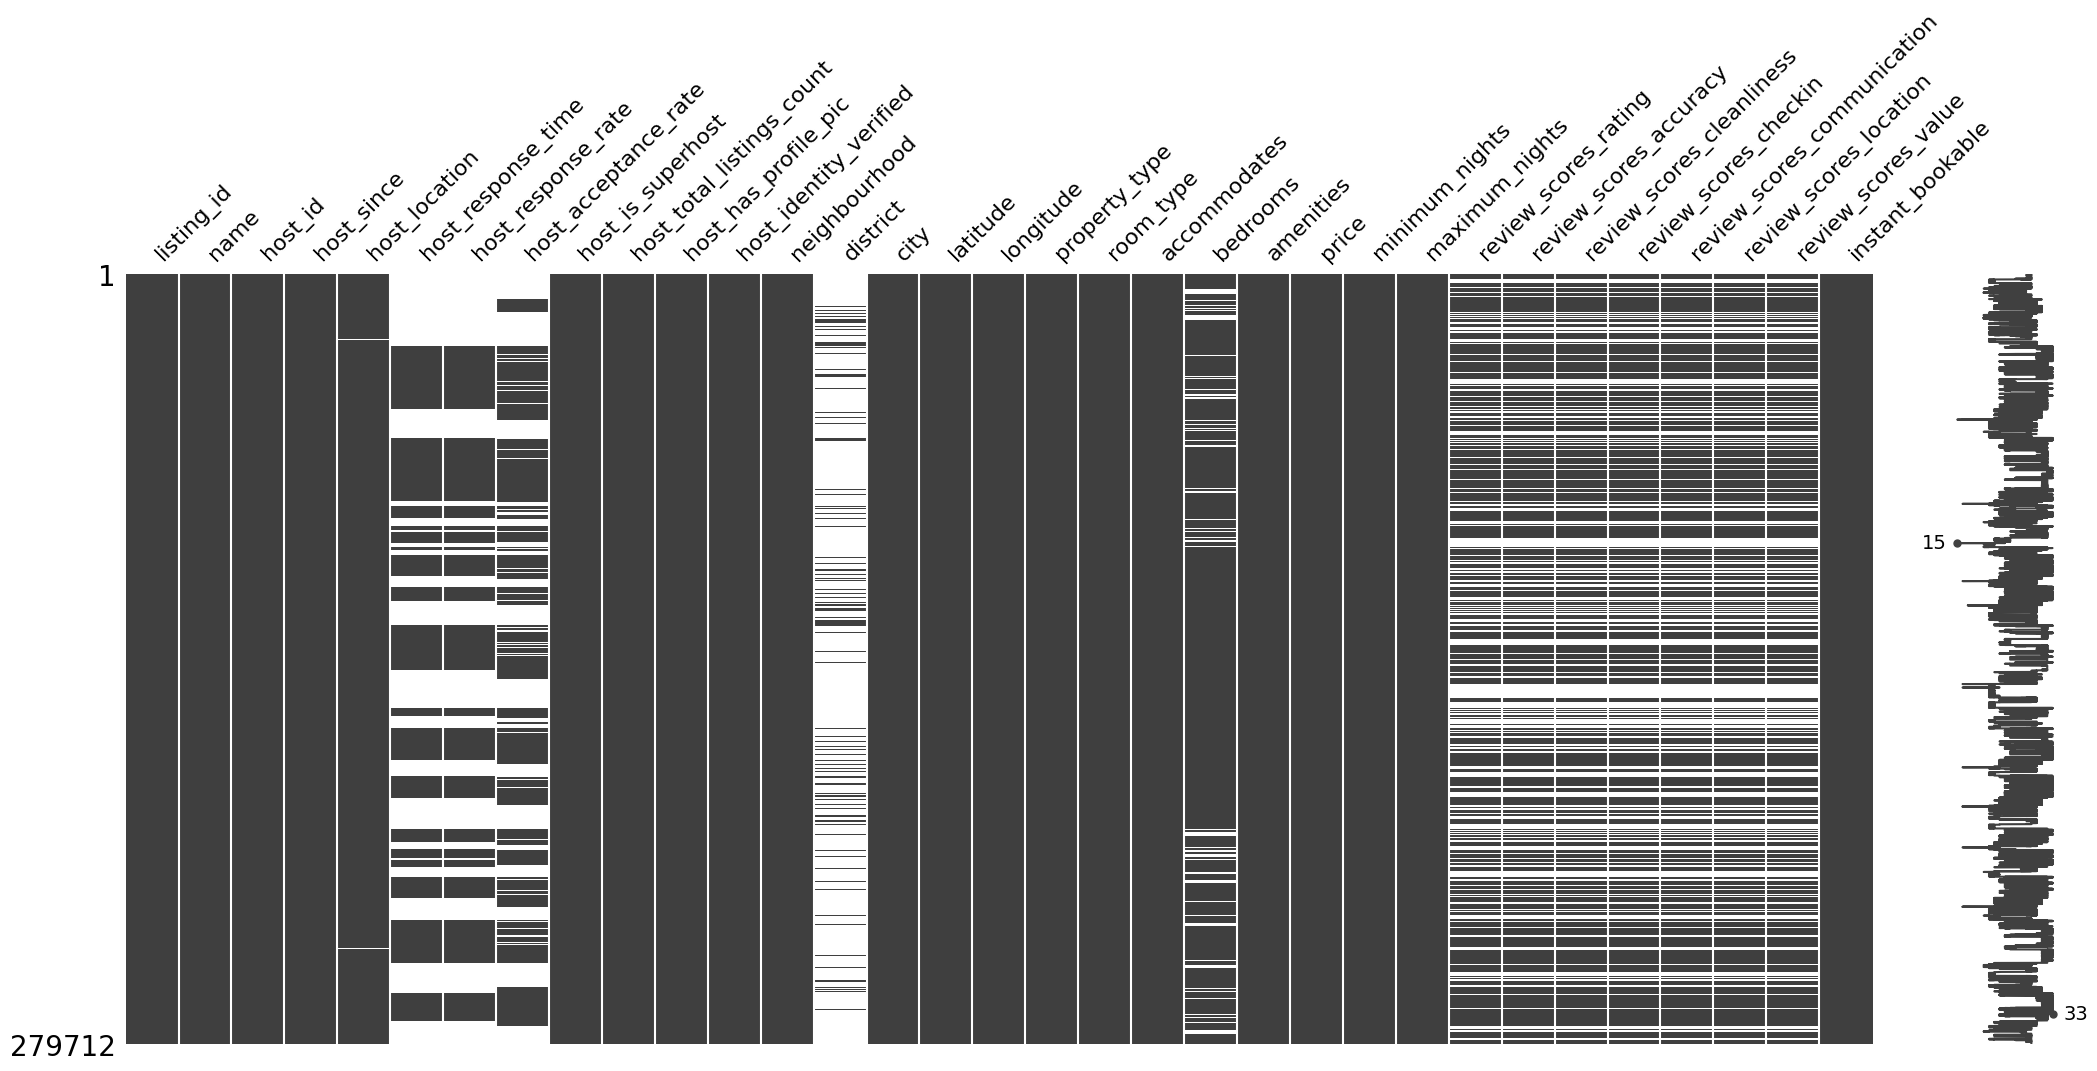

In [30]:
import missingno as msno
msno.matrix(df_listing.to_pandas())

<Axes: >

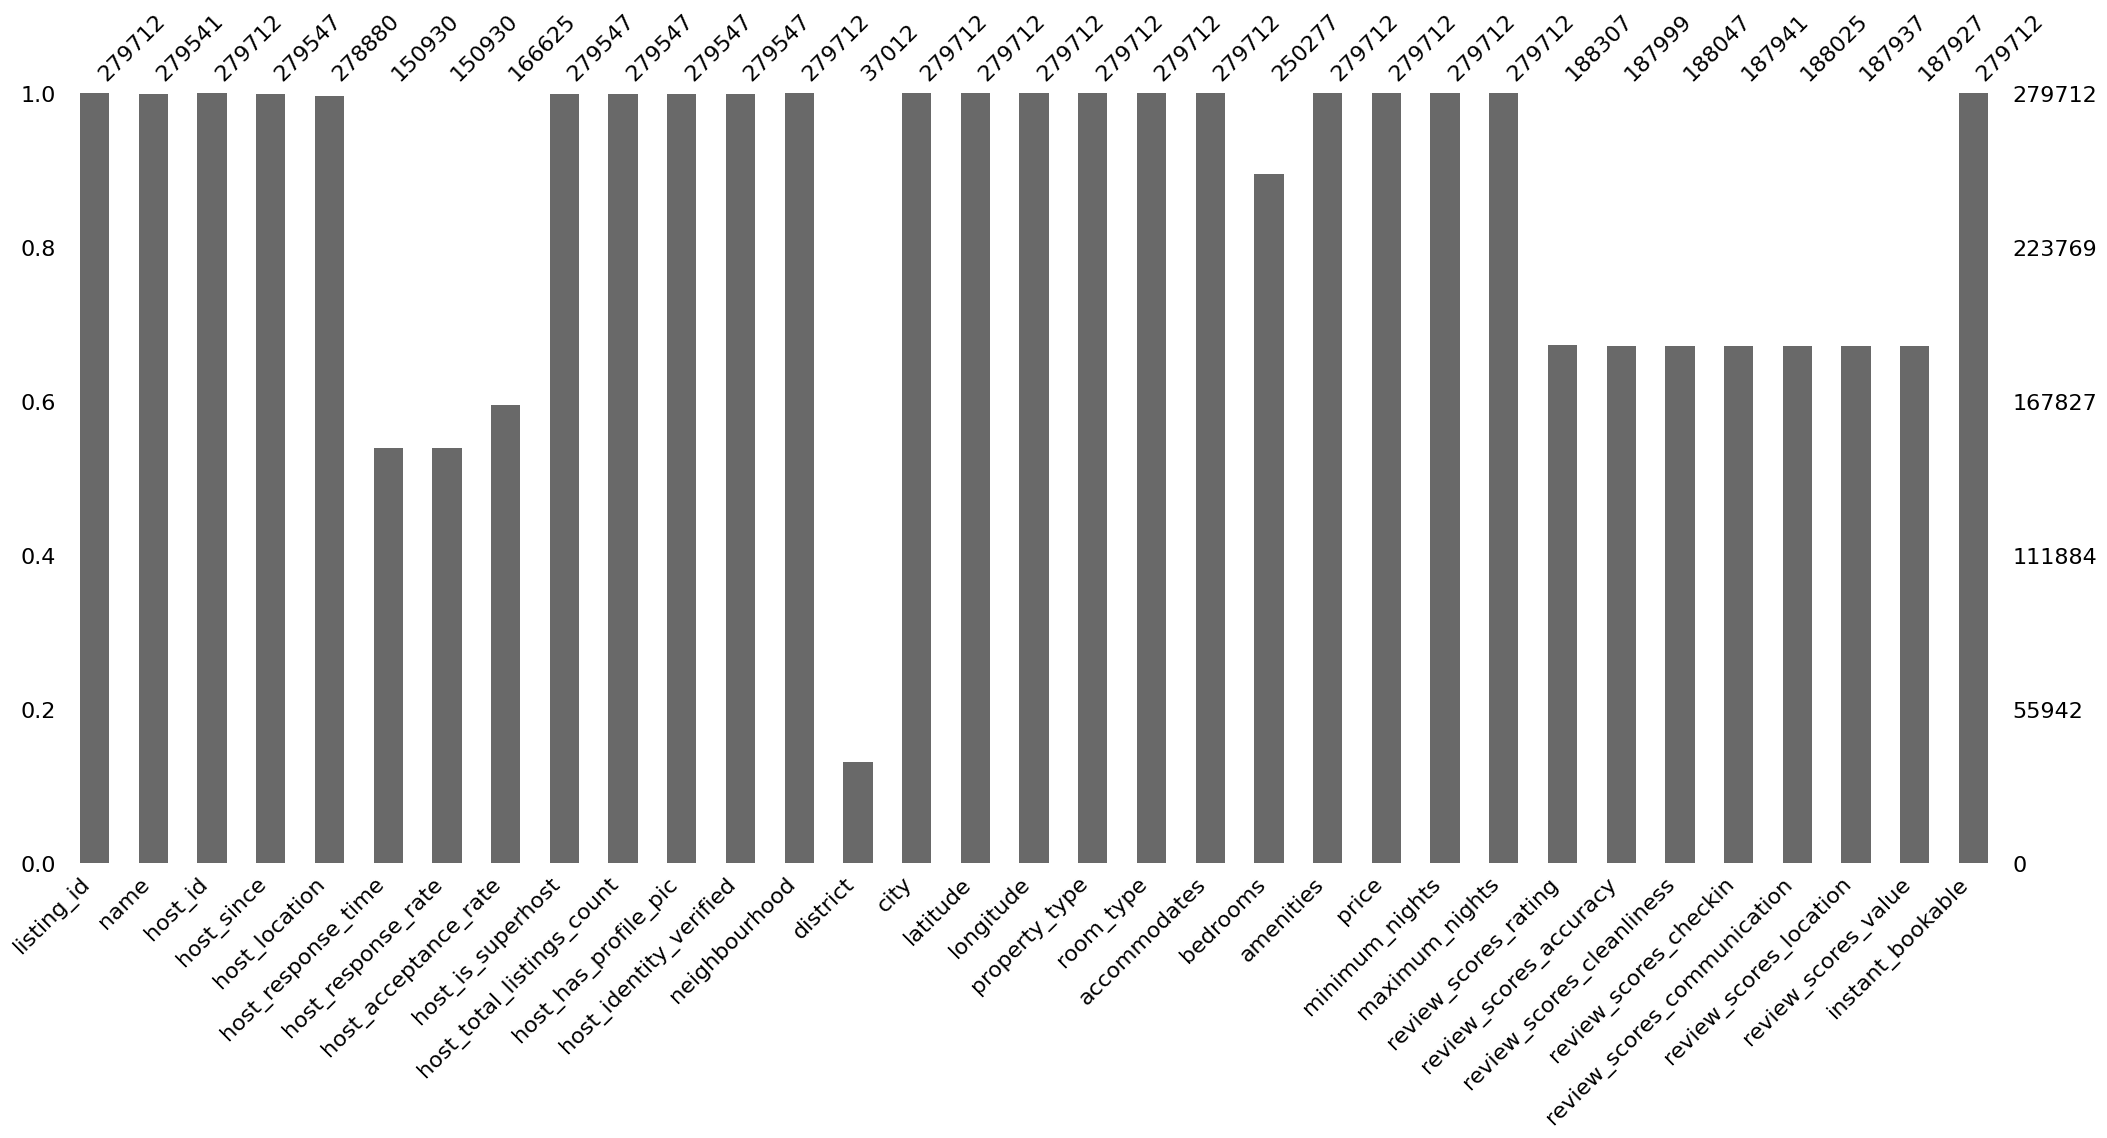

In [31]:
msno.bar(df_listing.to_pandas())

<Axes: >

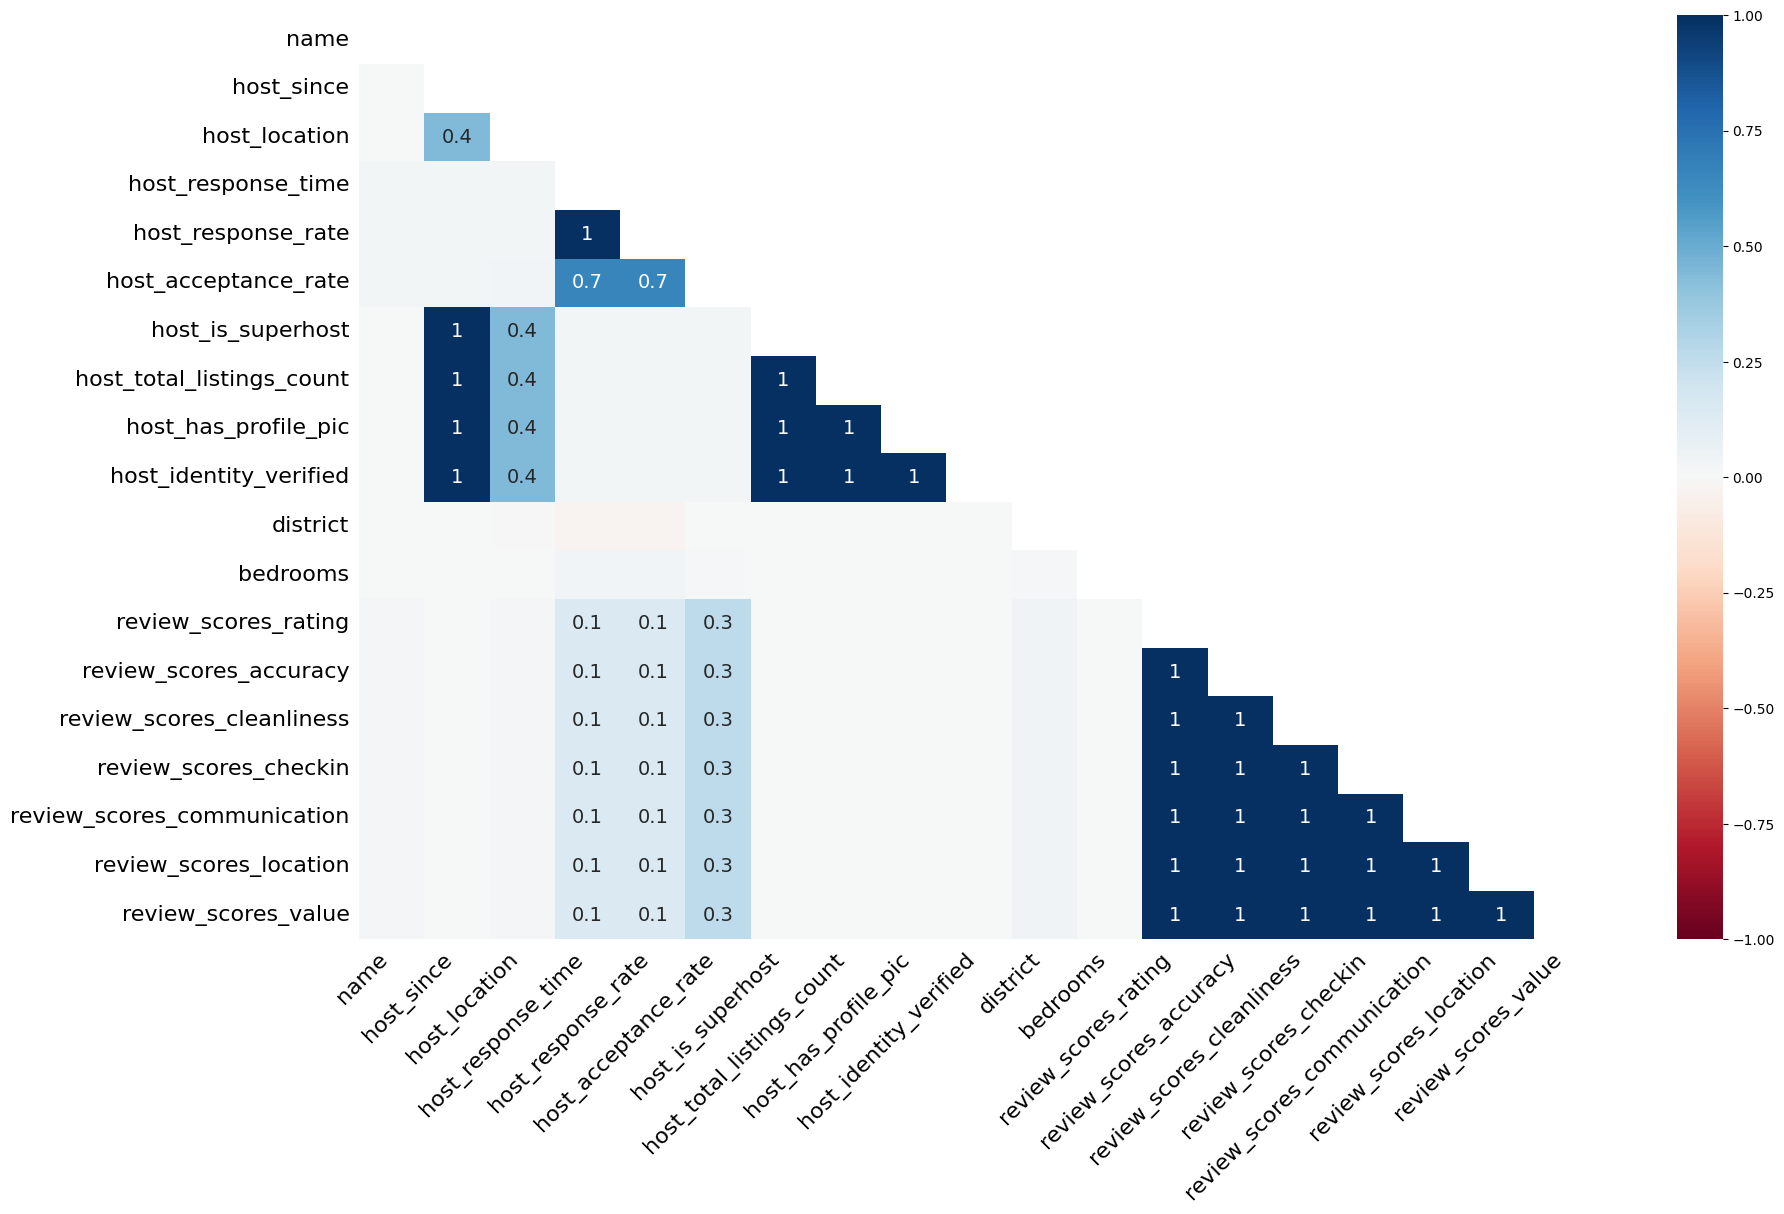

In [32]:
"""
The values range from -1 to 1.
1.0 (Dark Blue): Perfect Correlation. If Column A is missing, Column B is always missing.
Look at chart: host_is_superhost and host_since have a 1. This confirms they are tied together at the source

0.0 (Gray/Blank): No Correlation. Missing values in Column A tell you nothing about missing values in Column B.
Example: name has almost no correlation with anything else.

-1.0 (Dark Red): Inverse Correlation (Rare). If Column A is missing, Column B is never missing.

< 1.0 (e.g., 0.4 or 0.7): Strong but not perfect.
Example: host_response_time and host_acceptance_rate have a 0.7. This means they usually go missing together, but not always.

Weak correlation (0.1 - 0.3):
review_scores_* ↔ host_response_rate/time/acceptance_rate: Hosts who respond well get slightly better reviews — logical but not strongly predictive

Features with NO correlation (blank rows/cols): name, host_since, district, bedrooms — either categorical or weakly related to everything else, may need encoding or further investigation
"""
msno.heatmap(df_listing.to_pandas()) # Values near +1 = maybe missing together (MNAR)

- review_scores_* columns have the correlation = 1 -> maybe a group, so can check based on 1 column like review_scores_rating, no need check all single columns
- host_is_superhost, hoast_total_listings_count, host_has_profile_pic, host_indentity_verified and host_since also have corr score = 1 -> may be high relations
- host_location and (host_is_superhost, hoast_total_listings_count, host_has_profile_pic, host_indentity_verified) has score is 0.4, maybe have relation
- host_location and host_since also have relation
- host_reponse_rate, host_acceptance_rate and host_response_time also have high relation

<Axes: >

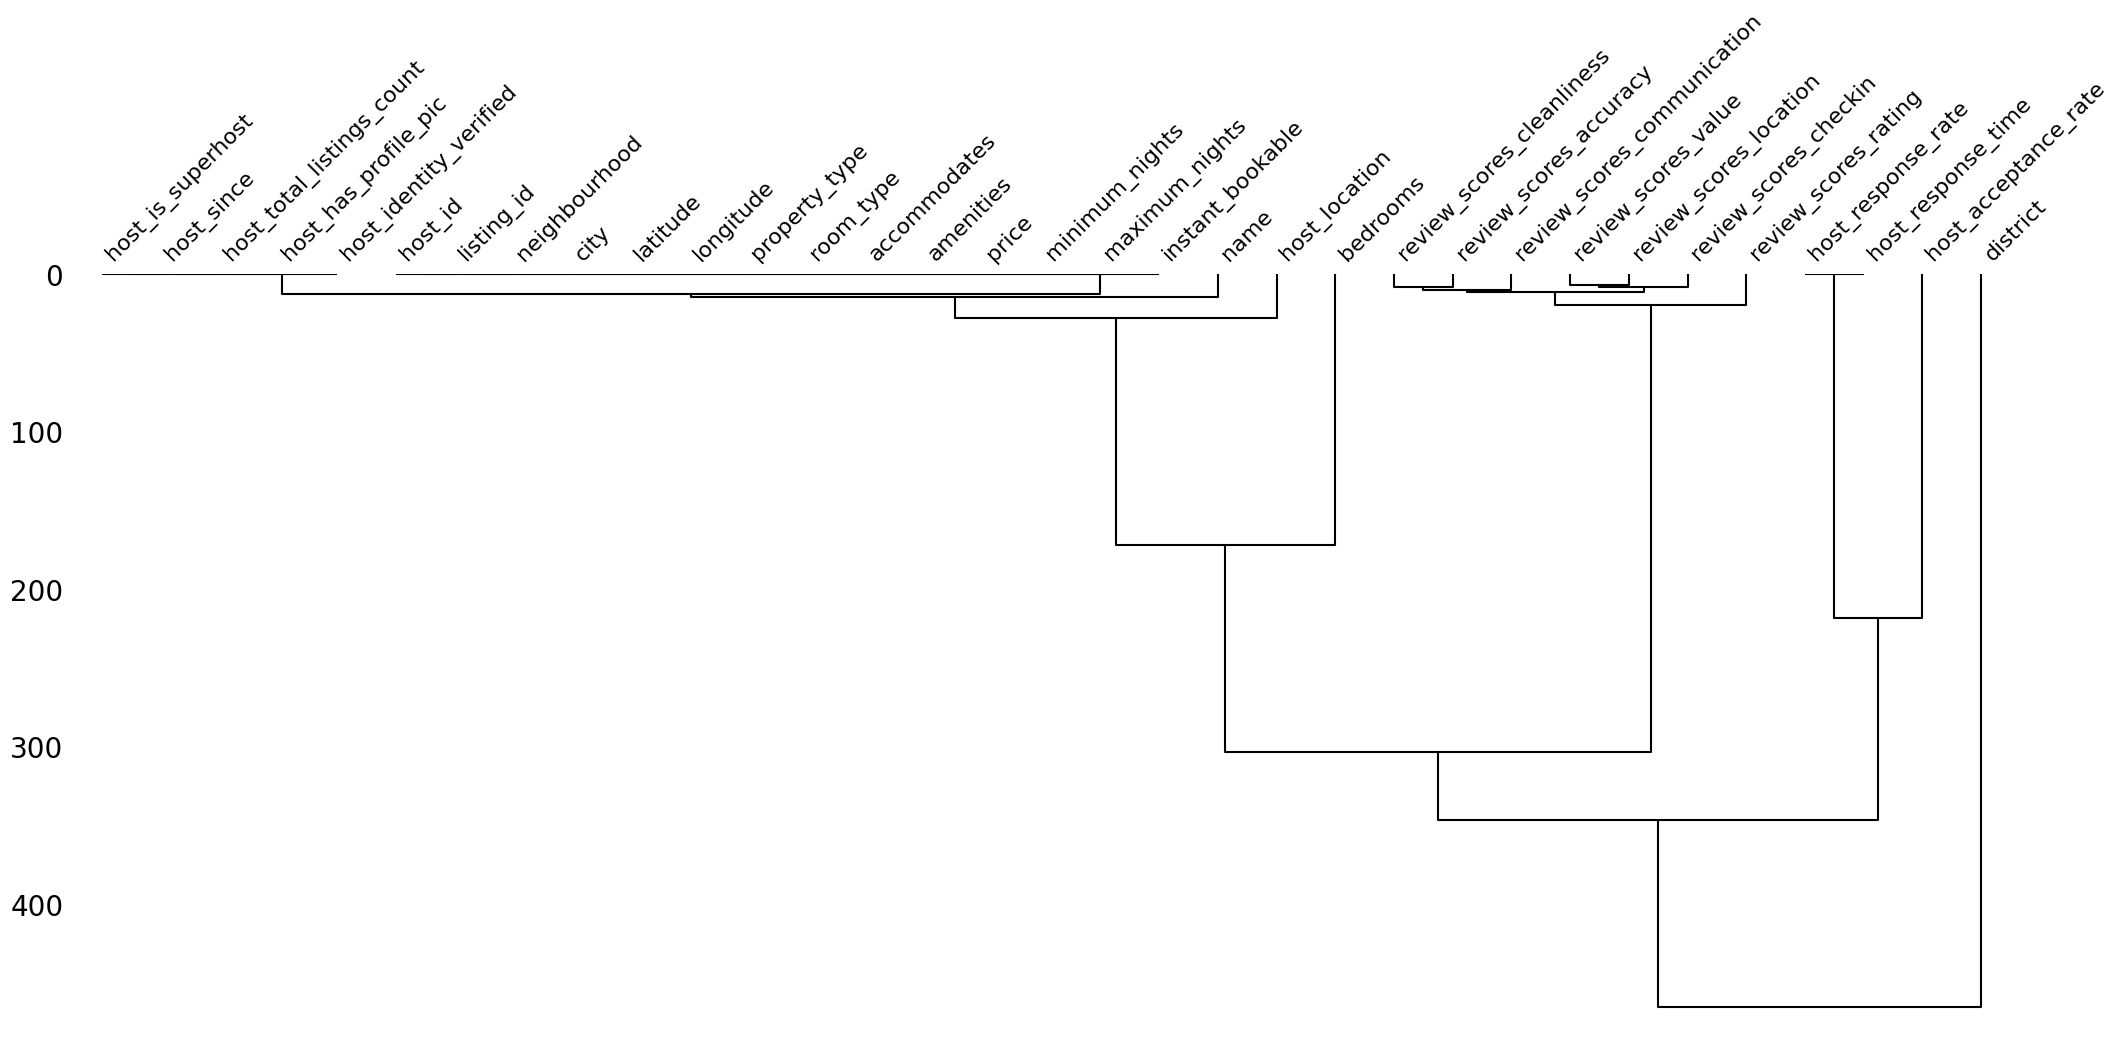

In [33]:
# display relationship between missing values and target variable
"""
1. The Horizontal Distance (Closeness) -> su tuong quan giua cac bien, cang gan 0 thi cac bien cang co su tuong quan lon
Columns that are connected by very short lines at the top are highly correlated.
Example: Look at host_is_superhost, host_since, and host_total_listings_count. They are all joined at the very top (near 0). This means that whenever one is missing, the others are almost certainly missing too. This suggests these fields come from the same source "Host Profile" object.

2. The Vertical Clusters (The Branches)
The deeper the "V" or "U" shape goes before connecting, the less correlated the missing data is.
The Right-Side Cluster: Notice review_scores_rating, review_scores_accuracy, etc., are grouped together. This makes sense: if a listing has no reviews, all the sub-scores will be null.
The Outliers: Columns like district or host_acceptance_rate connect much further down (near 300-400). This means their missingness is independent of the other groups.
"""
msno.dendrogram(df_listing.to_pandas()) # Tight cluster = same rows -> can be missing together

#### 3. Determine missing type: MCAR, MAR or MNAR
- Statistical test. p-value > 0.05 = MCAR (safe to drop/simple impute). p < 0.05 = not MCAR, need careful strategy.
- MNAR test
- ....
- If MCAR, rate < 5%, can try:
    - normal distribution: mean
    - skew distribution: median
    - categorical data type: mode

In [34]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [35]:
df_listing_pandas = df_listing.to_pandas()

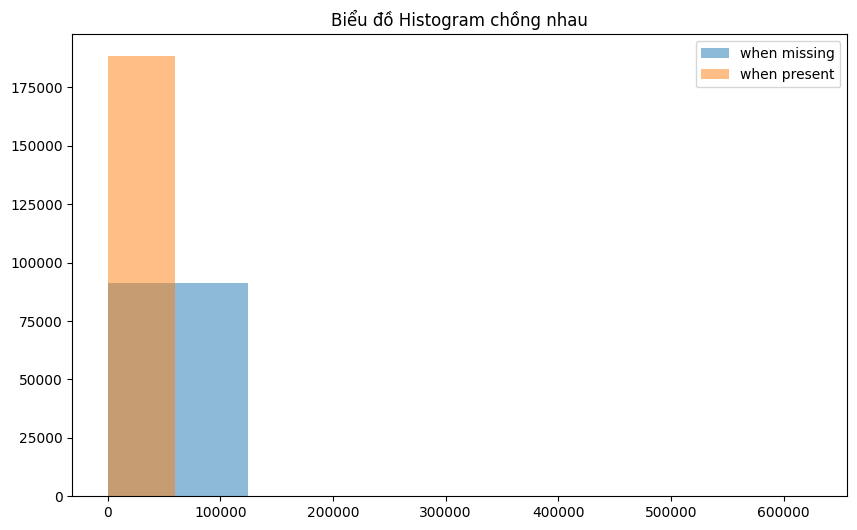

In [36]:
# Compare distributions of other columns when column X is present vs. missing. Difference = MAR or MNAR evidence.
mask = df_listing_pandas['review_scores_rating'].isna()
plt.figure(figsize=(10,6))
plt.hist(df_listing_pandas[mask]['price'], bins=5, alpha=0.5, label='when missing')
plt.hist(df_listing_pandas[~mask]['price'], bins=5, alpha=0.5, label='when present')
plt.legend(loc='upper right') # loc giúp thay đổi vị trí chú thích
plt.title('Biểu đồ Histogram chồng nhau')
# plt.xlabel('Giá trị')
# plt.ylabel('Tần suất')
plt.show()

In [37]:
# Statistical test. p-value > 0.05 = MCAR (safe to drop/simple impute). p < 0.05 = not MCAR, need careful strategy.

from pyampute.exploration.mcar_statistical_tests import MCARTest
import numpy as np

mcar = MCARTest(method="little")

result = mcar.little_mcar_test(df_listing_pandas.select_dtypes(include=[np.number]))

print(result) # < 0.05 -> likely MAR or MNAR else MCAR


0.0


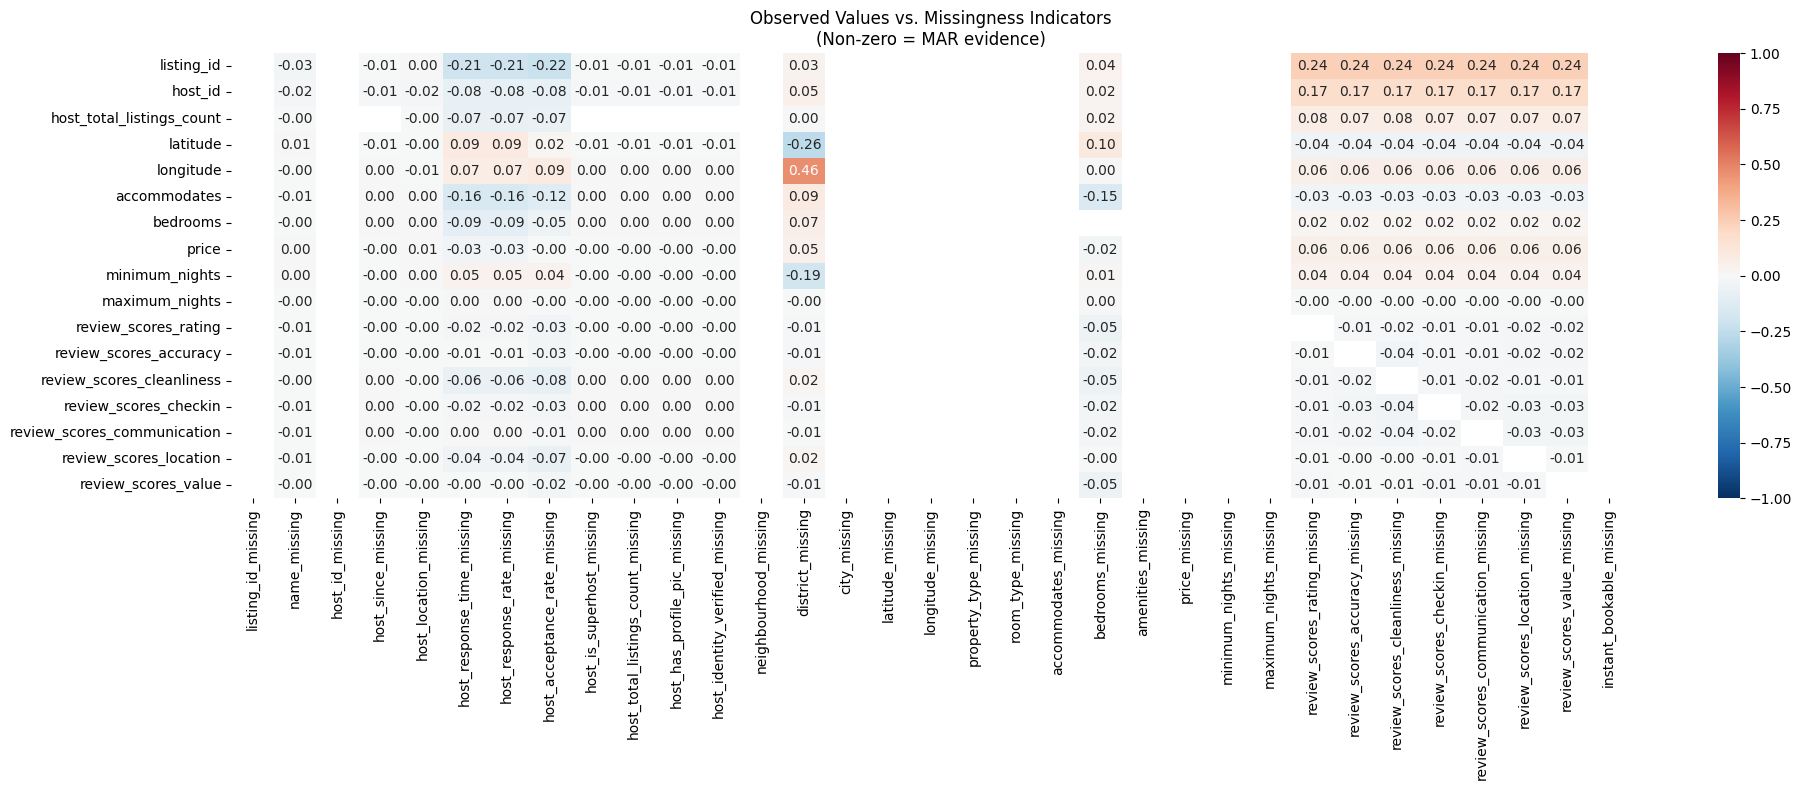

In [38]:
"""
This code is a Missing At Random (MAR) exploration technique.
It tries to answer:
“Can the missingness of one column be predicted from other observed numeric columns?”
If yes → this is evidence that the missing data may be MAR rather than completely random.

| Correlation                  | Meaning                             |
| ---------------------------- | ----------------------------------- |
| near 0                       | little/no relationship              |
| positive                     | larger values → more missing        |
| negative                     | larger values → less missing        |
| strong absolute value (>0.3) | potentially meaningful MAR evidence |

Pandas computes pairwise correlations between ALL columns.

Including:

observed vs observed
missingness vs missingness
observed vs missingness

The important part is: Corr(X,M)
X = observed variable
M = missingness indicator

If correlation ≈ 0 -> missingness unrelated to observed data -> evidence toward MCAR
If correlation ≠ 0 -> missingness depends on observed data -> evidence toward MAR

Interpreting Results in Practice
| Pattern                                 | Interpretation            |
| --------------------------------------- | ------------------------- |
| all correlations near 0                 | possible MCAR             |
| structured correlations                 | evidence toward MAR       |
| blocks of correlated missingness        | systemic collection issue |
| strong correlation with time variables  | temporal missingness      |
| strong correlation with target variable | leakage risk              |

"""
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create missingness indicators
missing_indicators = df_listing_pandas.isnull().astype(int)
missing_indicators = missing_indicators.add_suffix('_missing')

# Correlate missingness flags with observed numeric data
numeric_df = df_listing_pandas.select_dtypes(include=[np.number])
correlation_data = pd.concat([numeric_df, missing_indicators], axis=1)

# Compute correlation between observed values and missingness flags
mar_test_corr = correlation_data.corr()
missing_cols = [c for c in mar_test_corr.columns if '_missing' in c]
observed_cols = [c for c in mar_test_corr.columns if '_missing' not in c]

# Plot: Are observed values predictive of missingness?
plt.figure(figsize=(20, 8))
sns.heatmap(
    mar_test_corr.loc[observed_cols, missing_cols],
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f'
)
plt.title('Observed Values vs. Missingness Indicators\n(Non-zero = MAR evidence)')
plt.tight_layout()

- These columns are likely missing together as a group:
review_scores_rating_missing
review_scores_accuracy_missing
review_scores_cleanliness_missing
review_scores_checkin_missing
review_scores_communication_missing
review_scores_location_missing
review_scores_value_missing
all have:
≈ 0.24 correlation with listing_id
≈ 0.17 with host_id
≈ 0.07–0.08 with host_total_listings_count
-> Structural missingness
-> maybe listing_id has no review will be lack all review_scores_* metrics
-> MAR or even deterministic missingness
=> not fillna(mean or median), use these instead:
create: has_review binary column to mark has review metric or missing
conditional imputation
or keep NaN intentionally

- district missing relates to logtitude and latitude
longitude vs district_missing = 0.46
latitude vs district_missing = -0.26
-> can be MAR because P(Missing district) != independent(latitude, logtitude)
-> Possible strategies:
KNN imputation
geospatial nearest neighbor
reverse geocoding
clustering

- host_reponse_* and acceptance:
host_response_time_missing
host_response_rate_missing
host_acceptance_rate_missing
relate to:
≈ -0.21 with listing_id
≈ -0.07 with host_total_listings_count
These fields probably disappear together.

Likely cause:
hosts without response settings
inactive hosts
new hosts
instant-book-only hosts

-> structured missingness

- For others:
missingness is weakly related to observed numeric values
Possible meanings:
close to MCAR
relationship is nonlinear
relationship depends on categorical variables instead
Pearson correlation insufficient

In [39]:
df_listing_pandas.columns

Index(['listing_id', 'name', 'host_id', 'host_since', 'host_location',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_total_listings_count',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'district', 'city', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bedrooms', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable'],
      dtype='str')

In [40]:
# Missing groups
review_cols = [
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value'
]
df_listing_pandas["has_review"] = df_listing_pandas[review_cols].notna().any(axis=1)

In [41]:
df_listing_pandas["host_response_rate_missing"] = df_listing_pandas["host_response_rate"].isna()
# misisng can be due to: new lost, inactive host or low quality listing,...?

In [42]:
# 1. Test MCAR
from pyampute.exploration.mcar_statistical_tests import MCARTest

mcar = MCARTest(method="little")
mcar.little_mcar_test(df_listing_pandas.select_dtypes(include=[np.number]))
# p < 0.05 -> not MCAR

np.float64(0.0)

In [43]:
#  2. Search for MAR evidence
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

target = df_listing_pandas["district"].isnull().astype(int)

X = df_listing_pandas[["latitude", "longitude", "price"]].fillna(0)

model = LogisticRegression()
model.fit(X, target)

pred = model.predict_proba(X)[:,1]

roc_auc_score(target, pred)

"""
| AUC   | Meaning                                  |
| ----- | ---------------------------------------- |
| ~0.5  | observed vars do not explain missingness |
| >0.7  | strong MAR evidence                      |
| >0.85 | highly structured missingness            |

"""

'\n| AUC   | Meaning                                  |\n| ----- | ---------------------------------------- |\n| ~0.5  | observed vars do not explain missingness |\n| >0.7  | strong MAR evidence                      |\n| >0.85 | highly structured missingness            |\n\n'

<Axes: xlabel='district', ylabel='price'>

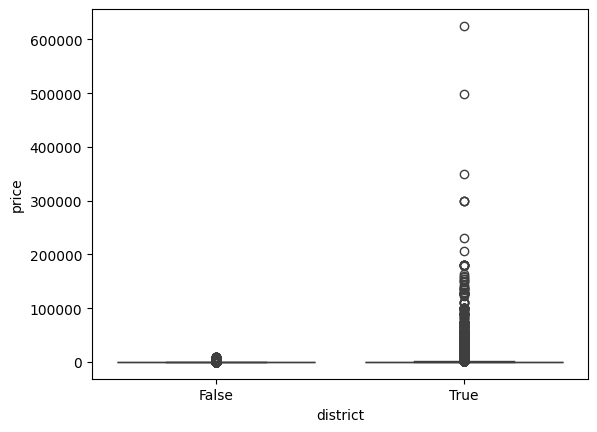

In [44]:
# 3. Compare Distributions Between Missing vs Non-Missing
sns.boxplot(
    x=df_listing_pandas["district"].isnull(),
    y=df_listing_pandas["price"]
)

<Axes: xlabel='district', ylabel='longitude'>

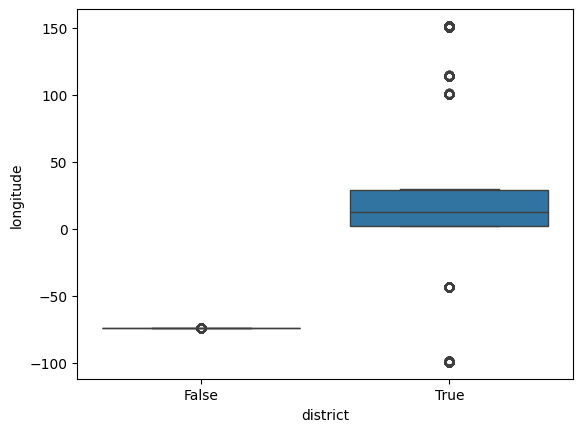

In [45]:
sns.boxplot(
    x=df_listing_pandas["district"].isnull(),
    y=df_listing_pandas["longitude"]
)

<Axes: xlabel='longitude', ylabel='latitude'>

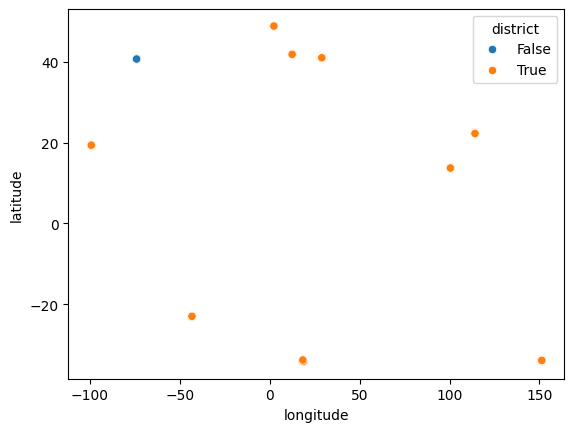

In [46]:
sns.scatterplot(
    x=df_listing_pandas["longitude"],
    y=df_listing_pandas["latitude"],
    hue=df_listing_pandas["district"].isnull()
)

In [47]:
df_listing_pandas[["latitude", "longitude"]].describe()

,latitude,longitude
count,279712.000000,279712.000000
mean,18.761862,12.595075
std,32.560343,73.081309
min,-34.264400,-99.339630
25%,-22.964390,-43.198040
50%,40.710785,2.382780
75%,41.908610,28.986730
max,48.904910,151.339810


In [48]:
pd.crosstab(
    df_listing_pandas["city"],
    df_listing_pandas["district"].isnull()
)

district,False,True
city,,
Bangkok,0,19361
Cape Town,0,19086
Hong Kong,0,7087
Istanbul,0,24519
Mexico City,0,20065
New York,37012,0
Paris,0,64690
Rio de Janeiro,0,26615
Rome,0,27647


<Axes: xlabel='district', ylabel='price'>

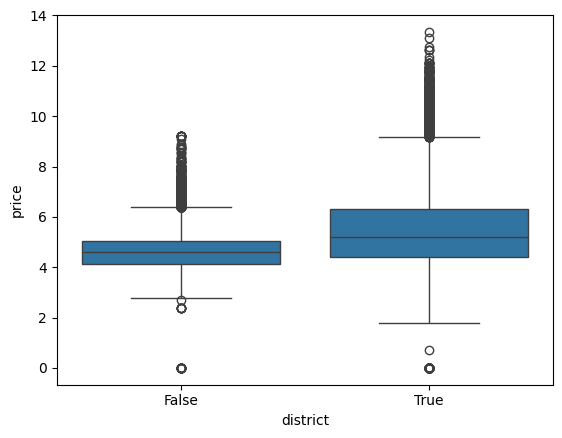

In [49]:
sns.boxplot(
    x=df_listing_pandas["district"].isnull(),
    y=np.log1p(df_listing_pandas["price"])
)

In [50]:
# 4. Sensitivity Analysis (Most Important for MNAR)
"""
you test:

“If missing values were systematically higher/lower, would conclusions change?”

Example

Impute salary using:

normal MAR imputation
+10%
-10%
worst-case

Then compare model results.

If conclusions stable:

good.

If conclusions change drastically:

missingness mechanism matters heavily.
"""

'\nyou test:\n\n“If missing values were systematically higher/lower, would conclusions change?”\n\nExample\n\nImpute salary using:\n\nnormal MAR imputation\n+10%\n-10%\nworst-case\n\nThen compare model results.\n\nIf conclusions stable:\n\ngood.\n\nIf conclusions change drastically:\n\nmissingness mechanism matters heavily.\n'

In [51]:
"""
Build missingness prediction models.

Especially for:

district_missing
response_rate_missing
review_score_missing

Use:

logistic regression
XGBoost
random forest
"""

'\nBuild missingness prediction models.\n\nEspecially for:\n\ndistrict_missing\nresponse_rate_missing\nreview_score_missing\n\nUse:\n\nlogistic regression\nXGBoost\nrandom forest\n'

In [52]:
# from little_mcar_test import mcar_test

# stat, p_value, df = mcar_test(df_listing_pandas)
# print(f"Little's MCAR test: χ²={stat:.2f}, p={p_value:.4f}, df={df}")

# if p_value < 0.05:
#     print("REJECT MCAR → Missingness is NOT random. Use MAR/MNAR methods.")
# else:
#     print("Fail to reject MCAR → Simple methods may be acceptable.")

#### 4. Try, judge and choose suitable method
- try some fill missing data method to find the most suitable method
- How to judge which is suitable?: MAE (mean absolute error) can be a method to judge

shape: (1, 4)
┌───────────┬────────┬──────────┬───────────┐
│ mean      ┆ median ┆ skewness ┆ kurtosis  │
│ ---       ┆ ---    ┆ ---      ┆ ---       │
│ f64       ┆ f64    ┆ f64      ┆ f64       │
╞═══════════╪════════╪══════════╪═══════════╡
│ 93.405195 ┆ 96.0   ┆ -3.75842 ┆ 19.998195 │
└───────────┴────────┴──────────┴───────────┘


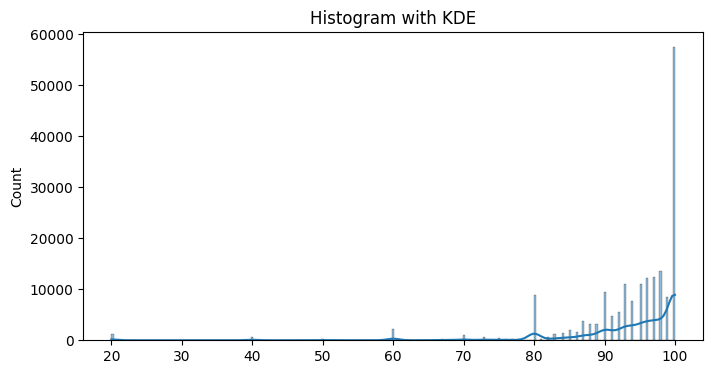

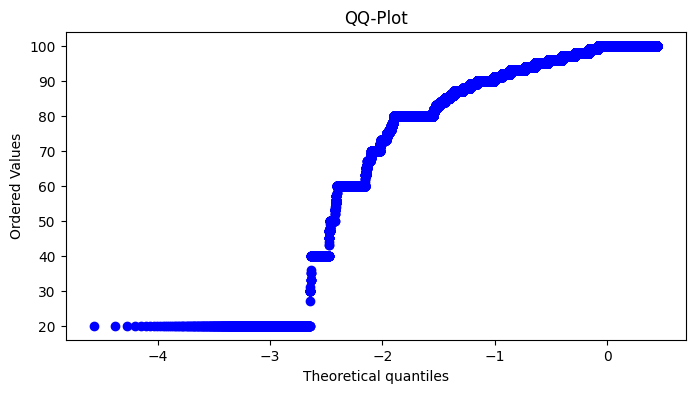

In [53]:
# Calculate normal distribution (tinh phan phoi chuan)
# https://www.datacamp.com/tutorial/normality-test

import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Tính các chỉ số
# Dữ liệu chuẩn thường có:
# Mean approx Median (Trung bình gan bang Trung vị)
# Skewness approx 0 (Độ lệch)
# Kurtosis approx 0 (Độ nhọn - theo định nghĩa Fisher)
# Nếu |Skewness| > 1 hoặc |Kurtosis| > 1
# dữ liệu có khả năng lệch nhiều so với phân phối chuẩn
stats_df = df_listing.select([
    pl.col("review_scores_rating").mean().alias("mean"),
    pl.col("review_scores_rating").median().alias("median"),
    pl.col("review_scores_rating").skew().alias("skewness"),
    pl.col("review_scores_rating").kurtosis(fisher=True).alias("kurtosis")
])
print(stats_df)

# 1.1 Histogram: Kiểm tra xem dữ liệu có hình chuông không.
plt.figure(figsize=(8,4))
sns.histplot(df_listing["review_scores_rating"], kde=True)
plt.title("Histogram with KDE")
plt.show()

# 1.2 QQ-Plot: : Kiểm tra xem các điểm dữ liệu có nằm trên đường thẳng chéo không
plt.figure(figsize=(8,4))
stats.probplot(df_listing["review_scores_rating"], dist="norm", plot=plt)
plt.title("QQ-Plot")
plt.show()


In [54]:
# Kiểm định Shapiro-Wilk (Statistical Test)
# Đây là phương pháp phổ biến để kiểm tra phân phối chuẩn
# H0 (Null Hypothesis): Dữ liệu tuân theo phân phối chuẩn.
# H1 (Alternative Hypothesis): Dữ liệu không tuân theo phân phối chuẩn.
# Nếu p-value > 0.05: Không đủ cơ sở bác bỏ H0 -> Dữ liệu có thể là phân phối chuẩn.
# Nếu p-value <= 0.05: Bác bỏ H0 -> Dữ liệu không phải phân phối chuẩn.

from scipy.stats import shapiro, stats, kstest, normaltest


data = df_listing_pandas["review_scores_rating"].dropna().to_numpy()
stat, p = shapiro(data) # For N > 5000, computed p-value may not be accurate

print(f"Shapiro-Wilk Test: Statistics={stat:.3f}, p-value={p:.3f}")

if p > 0.05:
    print("Dữ liệu có vẻ là phân phối chuẩn (không đủ cơ sở bác bỏ H0)")
else:
    print("Dữ liệu không tuân theo phân phối chuẩn (bác bỏ H0)")

stat, p_value = kstest(data, 'norm', args=(data.mean(), data.std()))
print(f"Kolmogorov-Smirnov test: {stat:.4f}, p-value: {p_value:.4f}")

stat, p_value = normaltest(data)
print(f"D'Agostino-Pearson test: {stat:.4f}, p-value: {p_value:.4f}")
# if not normal distribution, if need fill missing values, priotity meadian (trung vi) more than mean (trung binh)

Shapiro-Wilk Test: Statistics=0.626, p-value=0.000
Dữ liệu không tuân theo phân phối chuẩn (bác bỏ H0)
Kolmogorov-Smirnov test: 0.2563, p-value: 0.0000
D'Agostino-Pearson test: 149886.9142, p-value: 0.0000


/home/user/dapractice/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 188307.
  res = hypotest_fun_out(*samples, **kwds)


In [55]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import numpy as np

In [ ]:
"""
Recommended Experimental Design
| Model            | Mean | Median | KNN | MICE | Native Missing |
| ---------------- | ---- | ------ | --- | ---- | -------------- |
| LinearRegression | ✓    | ✓      | ✓   | ✓    | ✗              |
| RandomForest     | ✓    | ✓      | ✓   | ✓    | ✗              |
| XGBoost          | ✓    | ✓      | ✓   | ✓    | ✓              |
| LightGBM         | ✓    | ✓      | ✓   | ✓    | ✓              |


Then evaluate:
MAE
RMSE
R²

This gives a strong practical and research-oriented analysis.
Source: Chat GPT

basically a standard ML preprocessing pipeline:
Raw Data
   ↓
Remove rows missing target
   ↓
Keep numeric features
   ↓
Remove target leakage
   ↓
Remove constant columns
   ↓
Remove highly missing columns
   ↓
Split train/test
   ↓
Impute missing values
   ↓
Train model
   ↓
Evaluate
"""

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import (
    SimpleImputer,
    KNNImputer,
    IterativeImputer
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# =========================================================
# Prepare data
# =========================================================

# Remove target column out of dataset
df_model = df_listing_pandas.dropna(subset=["review_scores_rating"])

# Select only numeric data
X = (
    df_model
    .select_dtypes(include=[np.number])
    .drop(columns=["review_scores_rating"], errors="ignore")
)

# Remove constant columns
X = X.loc[:, X.nunique() > 1] # X.nunique() count unique value amount, if unique = 1, meaning column just contain one value, it has no meaning to check -> remove

# Remove highly missing columns
missing_ratio = X.isna().mean() # X.isna() return True if isna() else, when apply .mean() -> cast to 1 if True else False and count ratio (0 < ratio < 1) => count missing percentage
X = X.loc[:, missing_ratio < 0.7] # threshold = 0.7, or any number: 0.4, 0.5, 0.9,..., depend on: dataset size, business importance, modeling goals, ...

y = df_model["review_scores_rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================================================
# Imputation methods
# =========================================================

imputers = {
    "Mean": SimpleImputer(strategy="mean"),
    "Median": SimpleImputer(strategy="median"),
    # "KNN": KNNImputer(n_neighbors=5),
    "MICE": IterativeImputer(random_state=42, max_iter=10),
}

# =========================================================
# Models
# =========================================================

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    )
}

# =========================================================
# Evaluation
# =========================================================

results = []
for imputer_name, imputer in imputers.items():
    for model_name, model in models.items():
        pipeline = Pipeline([
            ("imputer", imputer),
            ("scaler", StandardScaler()),
            ("model", model)
        ])

        pipeline.fit(X_train, y_train)
        preds = pipeline.predict(X_test)
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)

        result = {
            "Imputer": imputer_name,
            "Model": model_name,
            "MAE": mae, # go from 0–100 -> less sensitive with outlier than RMSE
            "RMSE": rmse, # go from 0–100 -> sensitive with outliers, not good for business
            "R2": r2 # range 0 to 1
        }
        print(f"{result = }: ")
        results.append(result)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by=["MAE", "RMSE"]
)
print(results_df) # MAE vs RMSE lower -> better, R^2 higher -> better

# =========================================================
# Conclusion
# =========================================================
"""
Result: 2026-May-11 23:20 PM
Imputer             Model       MAE      RMSE        R2
6   Median           XGBoost  2.804437  4.575190  0.788051
2     Mean           XGBoost  2.805336  4.579225  0.787677
10    MICE           XGBoost  2.811485  4.582487  0.787375
11    MICE          LightGBM  2.812671  4.561221  0.789344
7   Median          LightGBM  2.814285  4.574737  0.788093
3     Mean          LightGBM  2.814357  4.569828  0.788548
1     Mean      RandomForest  2.884084  4.729266  0.773536
9     MICE      RandomForest  2.886839  4.724013  0.774039
5   Median      RandomForest  2.889355  4.729213  0.773541
8     MICE  LinearRegression  2.930197  4.693932  0.776907
4   Median  LinearRegression  2.931047  4.712459  0.775142
0     Mean  LinearRegression  2.934341  4.708277  0.775541

-> Median vs XGboost is best for this dataset
Here RMSE (~4.5–4.7) is noticeably higher than MAE (~2.8–2.9), so there are some outlier predictions the models struggle with.
"""

LinearRegression:  {'Imputer': 'Mean', 'Model': 'LinearRegression', 'MAE': 2.9343414045260108, 'RMSE': np.float64(4.708276729919548), 'R2': 0.7755413911208163}
RandomForest:  {'Imputer': 'Mean', 'Model': 'RandomForest', 'MAE': 2.8840839174765014, 'RMSE': np.float64(4.729266307473899), 'R2': 0.7735356496752207}
XGBoost:  {'Imputer': 'Mean', 'Model': 'XGBoost', 'MAE': 2.8053356656531383, 'RMSE': np.float64(4.579224508117917), 'R2': 0.7876774220944506}
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014718 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1779
[LightGBM] [Info] Number of data points in the train set: 150645, number of used features: 16
[LightGBM] [Info] Start training from score 93.391450


/home/user/dapractice/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM:  {'Imputer': 'Mean', 'Model': 'LightGBM', 'MAE': 2.8143573903091283, 'RMSE': np.float64(4.569827581488692), 'R2': 0.7885479330512457}
LinearRegression:  {'Imputer': 'Median', 'Model': 'LinearRegression', 'MAE': 2.93104727606307, 'RMSE': np.float64(4.712459146568696), 'R2': 0.7751424356468698}
RandomForest:  {'Imputer': 'Median', 'Model': 'RandomForest', 'MAE': 2.889354756341494, 'RMSE': np.float64(4.729213355488781), 'R2': 0.7735407209353251}
XGBoost:  {'Imputer': 'Median', 'Model': 'XGBoost', 'MAE': 2.8044371306880382, 'RMSE': np.float64(4.5751903549991795), 'R2': 0.7880513563687351}
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011351 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1777
[LightGBM] [Info] Number of data points in the train set: 150645, number of used features: 16
[LightGBM] [Info] Start training from score 

/home/user/dapractice/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM:  {'Imputer': 'Median', 'Model': 'LightGBM', 'MAE': 2.814284888813219, 'RMSE': np.float64(4.5747366715695), 'R2': 0.788093388639537}
LinearRegression:  {'Imputer': 'MICE', 'Model': 'LinearRegression', 'MAE': 2.9301969921255338, 'RMSE': np.float64(4.693932284606332), 'R2': 0.776906998850261}
RandomForest:  {'Imputer': 'MICE', 'Model': 'RandomForest', 'MAE': 2.8868388972337913, 'RMSE': np.float64(4.7240125062920155), 'R2': 0.7740385343566721}
XGBoost:  {'Imputer': 'MICE', 'Model': 'XGBoost', 'MAE': 2.811484748638162, 'RMSE': np.float64(4.582486582629217), 'R2': 0.787374812443288}
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.049316 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2967
[LightGBM] [Info] Number of data points in the train set: 150645, number of used features: 16
[LightGBM] [Info] Start training from score 93.39145

/home/user/dapractice/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM:  {'Imputer': 'MICE', 'Model': 'LightGBM', 'MAE': 2.812671356941434, 'RMSE': np.float64(4.561220786129756), 'R2': 0.7893436789810584}
   Imputer             Model       MAE      RMSE        R2
6   Median           XGBoost  2.804437  4.575190  0.788051
2     Mean           XGBoost  2.805336  4.579225  0.787677
10    MICE           XGBoost  2.811485  4.582487  0.787375
11    MICE          LightGBM  2.812671  4.561221  0.789344
7   Median          LightGBM  2.814285  4.574737  0.788093
3     Mean          LightGBM  2.814357  4.569828  0.788548
1     Mean      RandomForest  2.884084  4.729266  0.773536
9     MICE      RandomForest  2.886839  4.724013  0.774039
5   Median      RandomForest  2.889355  4.729213  0.773541
8     MICE  LinearRegression  2.930197  4.693932  0.776907
4   Median  LinearRegression  2.931047  4.712459  0.775142
0     Mean  LinearRegression  2.934341  4.708277  0.775541


In [108]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),

    ("model", XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1
    ))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fe

In [112]:
old_preds = pipeline.predict(X_test)
old_preds.mean()

np.float32(93.46077)

In [106]:
pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fe

In [111]:
model = XGBRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

new_preds = model.predict(X_test)
new_preds.mean()

np.float32(93.46332)

In [ ]:
new_preds.mean() - old_preds.mean() # No much change, can use pure XGBoost instead of combine median impute

np.float32(0.0025482178)

In [117]:
np.abs(np.median(new_preds) - np.median(old_preds))

np.float32(0.005722046)

In [ ]:
# fill for review_scores_rating using XGBoost, which have find most suitable for filling missing values

# 1. Separate known/missing targets
df_known = df_listing_pandas[
    df_listing_pandas["review_scores_rating"].notna()
]

df_missing = df_listing_pandas[
    df_listing_pandas["review_scores_rating"].isna()
]
# Remove outlier? -> no need now

# Build training data
X_train = df_known.select_dtypes(include=[np.number]).drop(
    columns=["review_scores_rating"]
)
y_train = df_known["review_scores_rating"]

# Build prediction data
X_missing = df_missing.select_dtypes(include=[np.number]).drop(
    columns=["review_scores_rating"]
)

# Train XGBoost
model = XGBRegressor(
    n_estimators=200,
    random_state=42
)
model.fit(X_train, y_train)

# Predict missing review scores
pred_missing = model.predict(X_missing)
print(pred_missing, pred_missing.shape)
print(df_listing_pandas.loc[
    df_listing_pandas["review_scores_rating"].isna(),
    "review_scores_rating"
].shape)
# # Fill missing review scores
# df_listing_pandas.loc[
#     df_listing_pandas["review_scores_rating"].isna(),
#     "review_scores_rating"
# ] = pred_missing

[92.772446 82.054214 84.942375 ... 85.90647  80.03555  92.08555 ] (91405,)
(91405,)


In [ ]:
#  Here RMSE (~4.5–4.7) is noticeably higher than MAE (~2.8–2.9), so there are some outlier predictions the models struggle with.

In [ ]:
# Have outliers, before determine remove or keep, do these

# 1. Analyze residuals
# Compute prediction errors:
# If want to check best strategy: median + XGBoost -> rerun pipeline :)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = XGBRegressor(
    n_estimators=200,
    random_state=42
)
pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", model)
        ])

pipeline.fit(X_train, y_train)
preds = pipeline.predict(X_test)
errors = y_test - preds
errors

65689     1.359734
275811   -2.354538
265506    1.423813
139498    1.344528
52808     4.402283
            ...   
92360    -2.797302
28487    -2.029312
173266    5.471977
263048    1.063492
99833     5.844910
Name: review_scores_rating, Length: 37662, dtype: float64

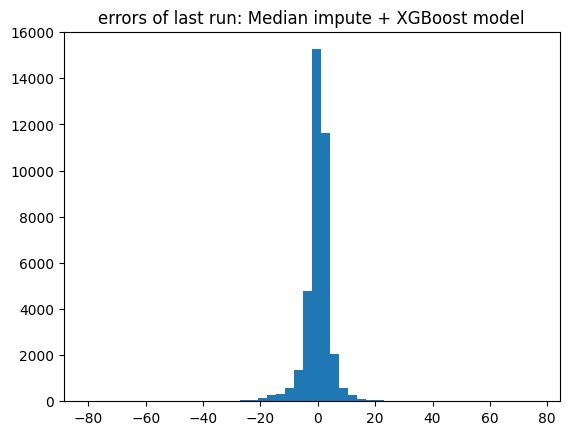

In [ ]:
# Plot residual distribution
"""
A good residual distribution usually has:
| Property          | Meaning                             |
| ----------------- | ----------------------------------- |
| centered near 0   | model unbiased overall              |
| symmetric         | no systematic over/under prediction |
| sharp center peak | most predictions close              |
| long tails        | difficult rare cases remain         |
-> A reasonably good model with hard edge cases
The long tails persisting even after XGBoost means:

The difficult cases are likely intrinsically hard,
not just due to weak modeling.
"""
import matplotlib.pyplot as plt

plt.hist(errors, bins=50) # bin = 50: divide range data into 50 equal-width distance, in each distant, count how many data it have, it is y value -> describe how much data in each range value
plt.title("errors of last run: Median impute + XGBoost model")
plt.show()

In [137]:
results = pd.DataFrame({
    "actual": y_test,
    "pred": preds,
})

results["abs_error"] = (
    results["actual"] - results["pred"]
).abs()

results.sort_values(
    "abs_error",
    ascending=False
).head(20)

,actual,pred,abs_error
206625,20.0,100.717590,80.717590
93405,100.0,23.518095,76.481905
41458,20.0,94.526466,74.526466
113647,20.0,84.584381,64.584381
61432,20.0,80.853333,60.853333
220948,20.0,77.977898,57.977898
157873,20.0,75.089828,55.089828
121516,20.0,74.173134,54.173134
179885,100.0,48.064907,51.935093
70340,100.0,50.015858,49.984142


<Axes: >

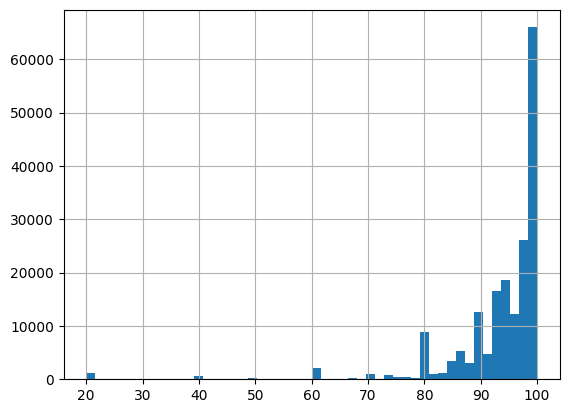

In [134]:
y.hist(bins=50)

In [138]:
(
    df_listing_pandas["review_scores_rating"]
    .value_counts(bins=10)
    .sort_index()
)

(19.919, 28.0]      1138
(28.0, 36.0]          36
(36.0, 44.0]         685
(44.0, 52.0]         286
(52.0, 60.0]        2264
(60.0, 68.0]         585
(68.0, 76.0]        2619
(76.0, 84.0]       13160
(84.0, 92.0]       33535
(92.0, 100.0]     133999
Name: count, dtype: int64

When SHOULD you remove outliers?

Only if:

data entry errors, 
impossible values, 
corrupted records, 
measurement failures, 

In [ ]:
# results_df.set_index(["Imputer", "Model"]).stack().reset_index().sort_values(by=[0], ascending=False)

,Imputer,Model,level_2,0
19,Mean,RandomForest,RMSE,4.729266
25,Median,RandomForest,RMSE,4.729213
22,MICE,RandomForest,RMSE,4.724013
31,Median,LinearRegression,RMSE,4.712459
34,Mean,LinearRegression,RMSE,4.708277
28,MICE,LinearRegression,RMSE,4.693932
7,MICE,XGBoost,RMSE,4.582487
4,Mean,XGBoost,RMSE,4.579225
1,Median,XGBoost,RMSE,4.575190
13,Median,LightGBM,RMSE,4.574737


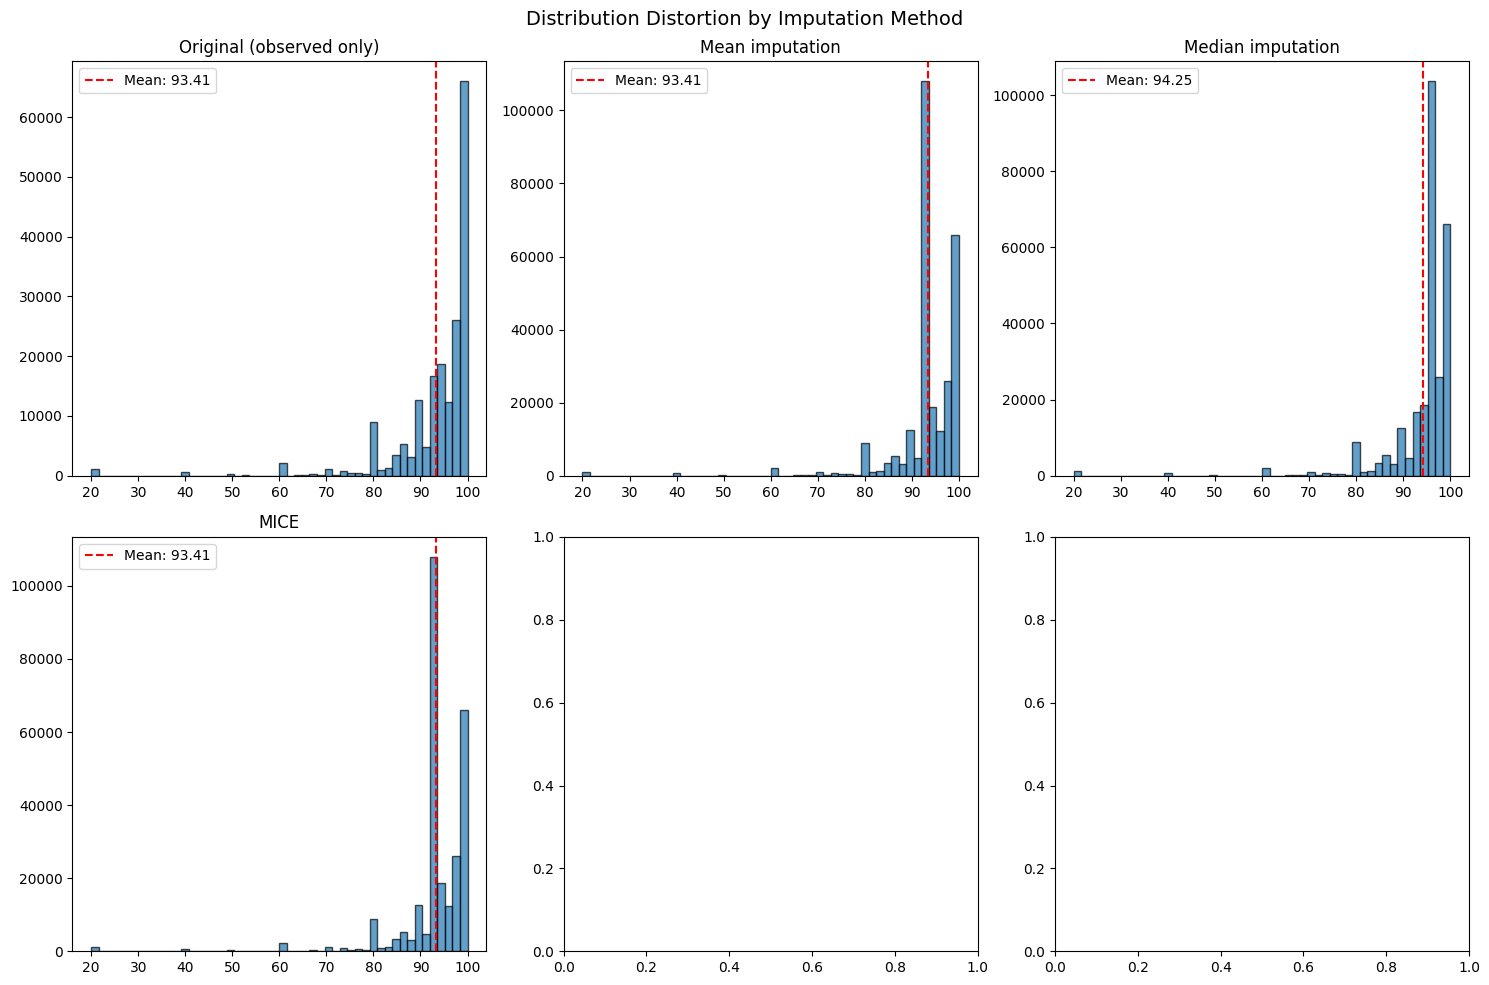

In [57]:


col = 'review_scores_rating'
data = df_listing_pandas[[col]].copy()

methods = {
    'Original (observed only)': data.dropna(),
    'Mean imputation': SimpleImputer(strategy='mean').fit_transform(data),
    'Median imputation': SimpleImputer(strategy='median').fit_transform(data),
    # 'KNN (k=5)': KNNImputer(n_neighbors=5).fit_transform(data),
    'MICE': IterativeImputer(random_state=42, max_iter=10).fit_transform(data)
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, values) in enumerate(methods.items()):
    ax = axes[idx]
    ax.hist(values, bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(np.mean(values), color='red', linestyle='--', label=f'Mean: {np.mean(values):.2f}')
    ax.set_title(name)
    ax.legend()

plt.suptitle('Distribution Distortion by Imputation Method', fontsize=14)
plt.tight_layout()

In [102]:
# Example: Are review scores missing more for new hosts?
df_listing_pandas['host_since'] = pd.to_datetime(
    df_listing_pandas['host_since'],
    errors='coerce'
)
df_listing_pandas['host_tenure_years'] = (pd.to_datetime('today') - pd.to_datetime(df_listing_pandas['host_since'])).dt.days / 365
print(df_listing_pandas['host_tenure_years'].value_counts().sort_index(ascending=True))
df_listing_pandas['is_new_host'] = df_listing_pandas['host_tenure_years'] < 6
print(df_listing_pandas['is_new_host'].value_counts())


missing_by_subgroup = df_listing_pandas.groupby('is_new_host').agg({
    'review_scores_rating': lambda x: x.isnull().mean(),
    'review_scores_accuracy': lambda x: x.isnull().mean(),
    'review_scores_cleanliness': lambda x: x.isnull().mean()
})

print(missing_by_subgroup.to_markdown())
"""
If new hosts had MUCH higher missingness:

Example:

is_new_host	missing rate
False	0.10
True	0.80

Then this strongly suggests:

Missing At Random (MAR)

because missingness depends on observed variable:

host tenure

This is extremely common in Airbnb datasets.
"""

host_tenure_years
5.205479      2
5.208219      1
5.210959      2
5.213699      4
5.216438     11
             ..
17.715068     1
17.728767     1
17.734247     4
17.753425    11
17.756164     1
Name: count, Length: 4240, dtype: int64
is_new_host
False    268567
True      11145
Name: count, dtype: int64
| is_new_host   |   review_scores_rating |   review_scores_accuracy |   review_scores_cleanliness |
|:--------------|-----------------------:|-------------------------:|----------------------------:|
| False         |               0.314149 |                 0.315296 |                    0.315117 |
| True          |               0.631225 |                 0.631225 |                    0.631225 |


'\nIf new hosts had MUCH higher missingness:\n\nExample:\n\nis_new_host\tmissing rate\nFalse\t0.10\nTrue\t0.80\n\nThen this strongly suggests:\n\nMissing At Random (MAR)\n\nbecause missingness depends on observed variable:\n\nhost tenure\n\nThis is extremely common in Airbnb datasets.\n'

In [ ]:
summary = (
    df_listing_pandas
    .groupby('is_new_host')
    .agg(
        total_rows=('review_scores_rating', 'size'),
        missing_count=(
            'review_scores_rating',
            lambda x: x.isnull().sum()
        ),
        missing_ratio=(
            'review_scores_rating',
            lambda x: x.isnull().mean()
        )
    )
)

print(summary)

#### 5. Statistical test. p-value > 0.05 = MCAR (safe to drop/simple impute). p < 0.05 = not MCAR, need careful strategy.

Fill missing data strategy:
- name: need unique, so fill null by "unknowm_name_" + row index
- host_location: as name
- for binary string as host_has_profile_pic, host_identity_verified, which can imply that can be True/False in realistic,  has missing data, so can apply strategy: "t", "f" and fill null by "na" as not given.
- for other string data like district, if having missing data, can fill "na" as not givent or "unknown" to imply that don't know data/missing.
- if missing data not have statistic meaning or no need pay attention, like district, can ignore or drop

for host_response_time, host_response_rate, ..., fill missing data or just calculate and statistics based on not na values?

for number data, how to deal with missing data without lossing realistic or cause biased (sai lech)
threshold nao de xac dinh fill na strategy:
If < thresold
- drop
If > threshold:
- fill mean/median/ffill/bfill (numeric data, for statistics) or fill default value (example: fill default for name)
- KNN/MICE

### Remove outliers

### Cast type

- after handle missing null, then cast type to willing data type.


In [59]:
df_listing = df_listing.with_columns(pl.col("host_response_rate").cast(pl.Float64))

In [60]:
df_listing = df_listing.with_columns(pl.col("host_acceptance_rate").cast(pl.Float64))

In [61]:
df_listing = df_listing.with_columns(pl.col("host_total_listings_count").cast(pl.Int64))

In [62]:
df_listing = df_listing.with_columns(pl.col("accommodates").cast(pl.Int64))

In [63]:
df_listing = df_listing.with_columns(pl.col("bedrooms").cast(pl.Int64))

In [64]:
df_listing = df_listing.with_columns(pl.col("minimum_nights").cast(pl.Int64))

In [65]:
df_listing = df_listing.with_columns(pl.col("maximum_nights").cast(pl.Int64))

### Convert to True/False (mapping value)

In [66]:
true_false_mapping: dict = {
    "t": True,
    "f": False
}
mapping_col: list = [
    "host_is_superhost",
    "host_has_profile_pic",
    "host_identity_verified",
    "instant_bookable"
]
df_listing = df_listing.with_columns([
    pl.col(col).map_elements(
        lambda x: true_false_mapping.get(x, None),
        return_dtype=pl.Boolean
    ).alias(col)
    for col in mapping_col
])
df_listing.head()

listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
f64,str,f64,str,str,str,f64,f64,bool,i64,bool,bool,str,str,str,f64,f64,str,str,i64,i64,str,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,bool
281420.0,"""Beautiful Flat in le Village M…",1.466919e6,"""2011-12-03""","""Paris, Ile-de-France, France""",null,null,null,false,1,true,false,"""Buttes-Montmartre""",null,"""Paris""",48.88668,2.33343,"""Entire apartment""","""Entire place""",2,1,"""[""Heating"", ""Kitchen"", ""Washer…",53.0,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,false
3.705183e6,"""39 m² Paris (Sacre Cœur)""",1.0328771e7,"""2013-11-29""","""Paris, Ile-de-France, France""",null,null,null,false,1,true,true,"""Buttes-Montmartre""",null,"""Paris""",48.88617,2.34515,"""Entire apartment""","""Entire place""",2,1,"""[""Shampoo"", ""Heating"", ""Kitche…",120.0,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,false
4.082273e6,"""Lovely apartment with Terrace,…",1.9252768e7,"""2014-07-31""","""Paris, Ile-de-France, France""",null,null,null,false,1,true,false,"""Elysee""",null,"""Paris""",48.88112,2.31712,"""Entire apartment""","""Entire place""",2,1,"""[""Heating"", ""TV"", ""Kitchen"", ""…",89.0,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,false
4.797344e6,"""Cosy studio (close to Eiffel t…",1.0668311e7,"""2013-12-17""","""Paris, Ile-de-France, France""",null,null,null,false,1,true,true,"""Vaugirard""",null,"""Paris""",48.84571,2.30584,"""Entire apartment""","""Entire place""",2,1,"""[""Heating"", ""TV"", ""Kitchen"", ""…",58.0,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,false
4.823489e6,"""Close to Eiffel Tower - Beauti…",2.4837558e7,"""2014-12-14""","""Paris, Ile-de-France, France""",null,null,null,false,1,true,false,"""Passy""",null,"""Paris""",48.855,2.26979,"""Entire apartment""","""Entire place""",2,1,"""[""Heating"", ""TV"", ""Kitchen"", ""…",60.0,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,false


### Categorize data/Enum data

In [67]:
# unique_property = df_listing["property_type"].fill_null("unknown_property").unique().sort()
# unique_property = pl.Enum(unique_property)
# unique_property

In [68]:
# df_enum = df_listing.with_columns(pl.col("property_type").cast(unique_property))
# df_enum.head()

In [69]:
# unique_rooms = df_listing["room_type"].fill_null("unknown_category").unique().sort()
# unique_rooms = pl.Enum(unique_rooms)
# print(unique_rooms)

In [70]:
# df_enum = df_enum.with_columns(pl.col("room_type").cast(unique_rooms))
# df_enum.head()

In [71]:
# Watch amenities data and each value amount
import polars as pl

df = df_listing.with_columns(
    pl.col("amenities").str.json_decode(dtype=pl.List(pl.Utf8)).alias("amenities")
)

df_explode = df.explode("amenities")

df_explode = (
    df_explode
    .select(pl.col("amenities").value_counts(sort=True))
    .unnest("amenities")
)

In [72]:
df_explode.shape

(3447, 2)

In [73]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_explode)

shape: (3_447, 2)
┌─────────────────────────────────┬────────┐
│ amenities                       ┆ count  │
│ ---                             ┆ ---    │
│ str                             ┆ u32    │
╞═════════════════════════════════╪════════╡
│ Wifi                            ┆ 260090 │
│ Essentials                      ┆ 253532 │
│ Long term stays allowed         ┆ 241054 │
│ Kitchen                         ┆ 240923 │
│ TV                              ┆ 213037 │
│ Hangers                         ┆ 211356 │
│ Hair dryer                      ┆ 188724 │
│ Iron                            ┆ 187756 │
│ Washer                          ┆ 185073 │
│ Heating                         ┆ 184327 │
│ Dedicated workspace             ┆ 179267 │
│ Shampoo                         ┆ 174082 │
│ Hot water                       ┆ 165163 │
│ Smoke alarm                     ┆ 156467 │
│ Air conditioning                ┆ 142693 │
│ Dishes and silverware           ┆ 123394 │
│ Refrigerator                    ┆ 1

## Next part

## Tranform data to utf8 for pandas reading

In [74]:
# ## Check file encoding
# import chardet

# def detect_file_encoding(filename):
#     with open(filename, 'rb') as file:
#         raw_data = file.read()
#         result = chardet.detect(raw_data)
#         return result['encoding']

# ## Usage
# print(detect_file_encoding(listing_file_path))

In [75]:
# pd.read_csv(listing_file_path, encoding='latin1')

In [76]:
# import chardet

# def validate_encoding(filename):
#     with open(filename, 'rb') as file:
#         raw_data = file.read()
#         result = chardet.detect(raw_data)

#     return {
#         'detected_encoding': result['encoding'],
#         'confidence': result['confidence']
#     }
# validate_encoding(listing_file_path)

In [77]:
# import codecs

# def normalize_file_encoding(input_file, output_file, target_encoding='utf-8'):
#     try:
#         with codecs.open(input_file, 'r', encoding='utf-8', errors='replace') as source:
#             content = source.read()

#         with codecs.open(output_file, 'w', encoding=target_encoding) as target:
#             target.write(content)

#         print(f"File converted to {target_encoding}")
#     except Exception as e:
#         print(f"Conversion error: {e}")
# normalize_file_encoding(listing_file_path, "listing_encoded.csv")

In [78]:
# pd.read_csv("listing_encoded.csv")

In [79]:
# import codecs

# def transcode_to_utf8(source_path, dest_path):
#     with open(source_path, "rb") as src, open(dest_path, "wb") as dst:
#         reader = codecs.iterdecode(src, "latin-1")
#         for line in reader:
#             dst.write(line.encode("utf-8"))

#     print("Transcoding complete.")

# transcode_to_utf8(listing_file_path, "listing_encoded_2.csv")


In [80]:
# pd.read_csv("listing_encoded_2.csv", encoding="utf8")

In [81]:
# def normalize_large_file(input_file, output_file):
#     with open(input_file, 'r', encoding='utf-8', errors='replace') as src:
#         with open(output_file, 'w', encoding='utf-8') as dest:
#             for line in src:  # Read one line at a time (Low RAM)
#                 dest.write(line)
#     print("Normalization complete")

# normalize_large_file(listing_file_path, "listing_encoded_3.csv")

In [82]:
# pd.read_csv("listing_encoded_3.csv")